<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/TALLER_MODULACION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**JULIAN DAVID MORALES PINEDA**
**Taller #1**

$I_d' = [0, 1, 1, 0, 0, 1]$

$d_i \in \{0, 1\}$, $i \in \{0, 1\}$

$a_i \in \{a_0, a_1 : a_i \in \mathbb{R}^+\}$

$d_i \rightarrow a_i$: $a_i v_i(t)$

$v'_i(t) = \text{rect}_T(t)$, para todo $t \in T$

$\phi_i(t) = 0$, para todo $i$.  ASK
--------------------------------------------------------------------------------------------
$V_i(t) = \text{Gauss}_T(t)$; para todo $i$, $t \in T$  **WASK**
-------------------------------------------------------------------------
$\phi_i(t) = d_i \pi$: para todo $i$, $t \in T$ **WPSK**
-------------------------------------------------------------------------------------------------
$\Phi_i(t) = (2d_i - 1)t$ Para $t \in T$

$\Phi_i(t) = (2d_i -1) \land \left(\frac{t-T}{T}\right)$ **WFSK**

SISTEMA DE MODULACIONES DIGITALES
Implementación en PyTorch - Teoría de Señales

[INFO] Parámetros del sistema:
  - Bits: [0, 1, 1, 0, 0, 1]
  - N_bits: 6
  - Tb: 0.5000 s
  - Rb: 2.00 bits/s
  - fc: 40.00 Hz
  - fs: 8000 Hz
  - Muestras: 24000

1. GENERACIÓN DE SEÑALES

[1/4] Generando señal ASK (pulsos rectangulares)...


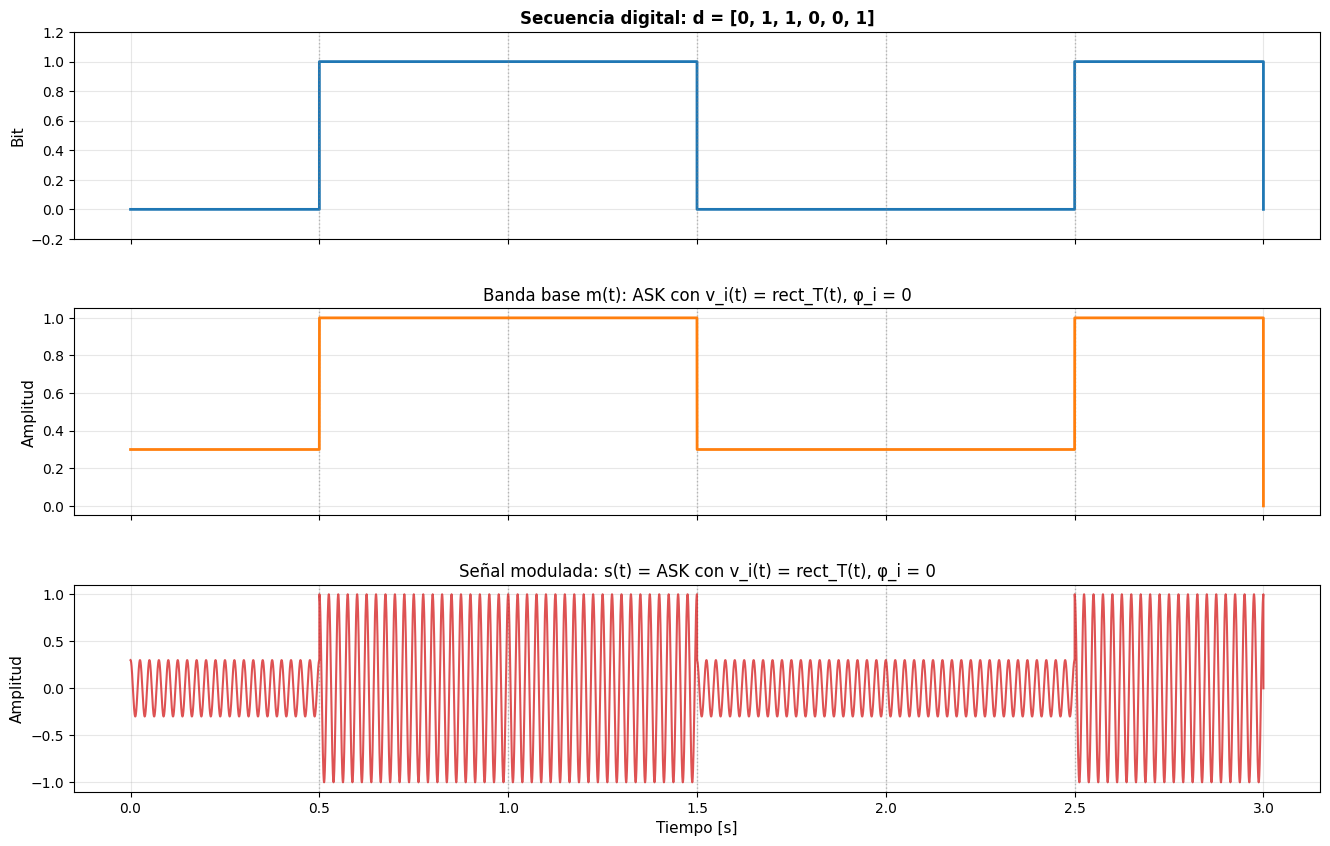

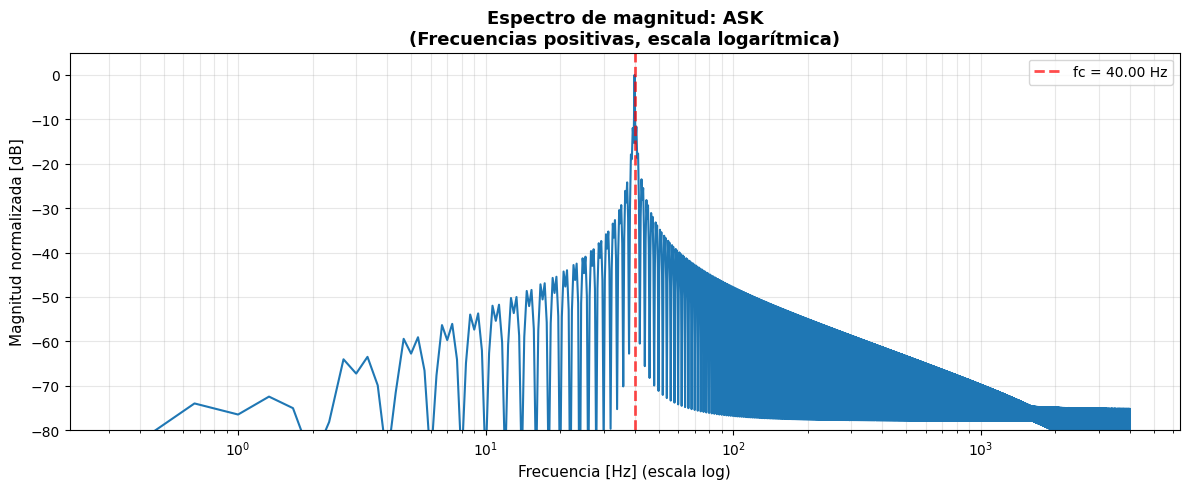


[2/4] Generando señal WASK (pulsos gaussianos)...


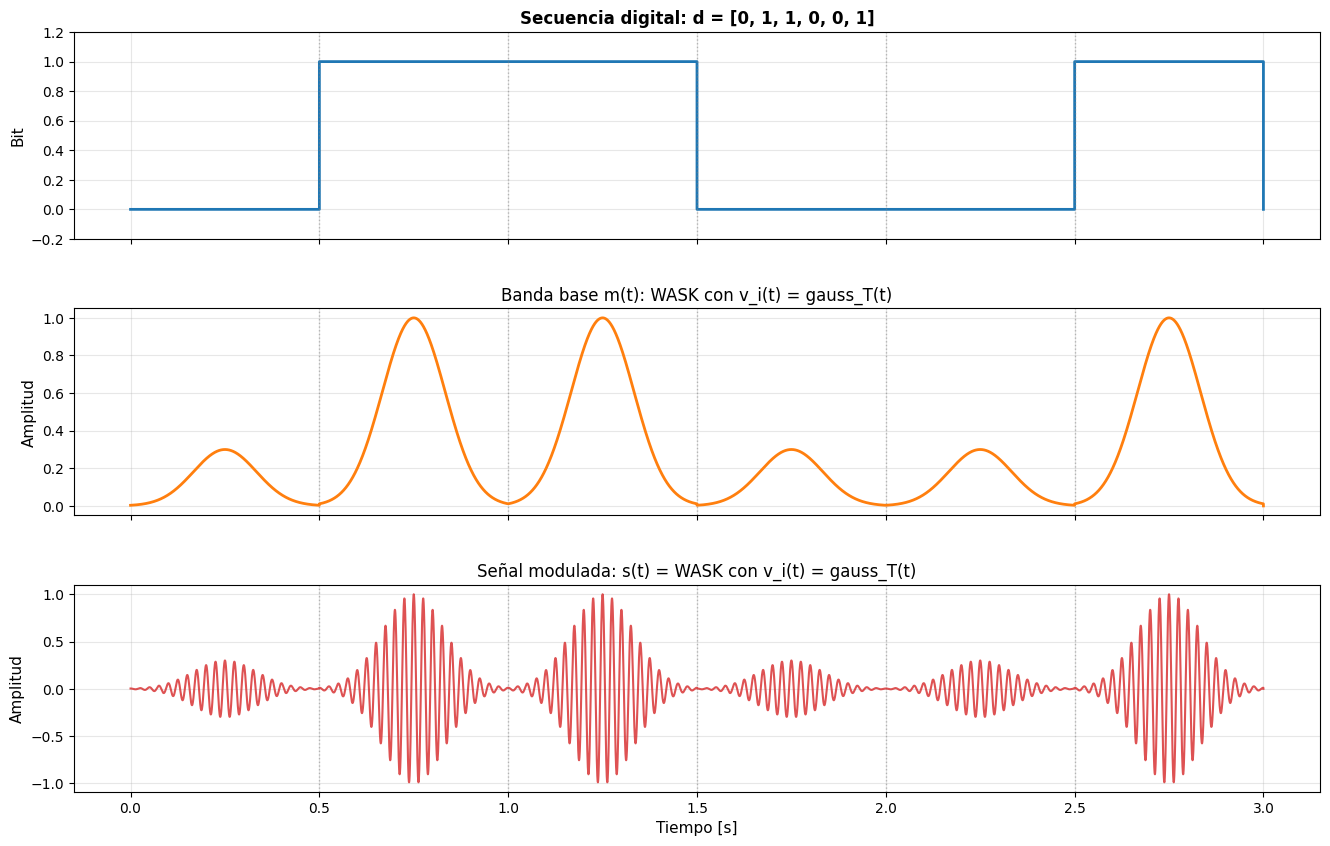

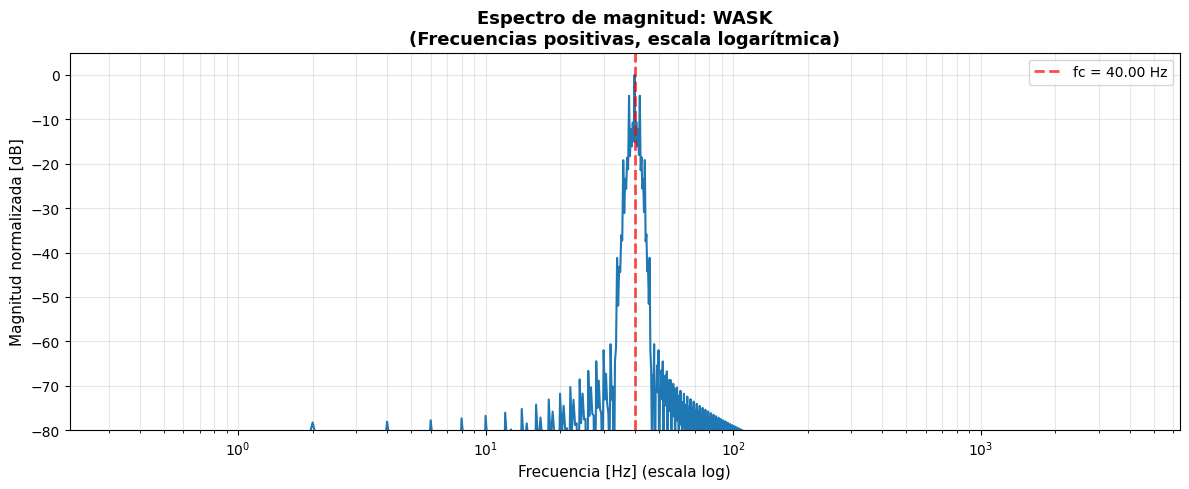


[3/4] Generando señal WPSK (modulación de fase binaria)...


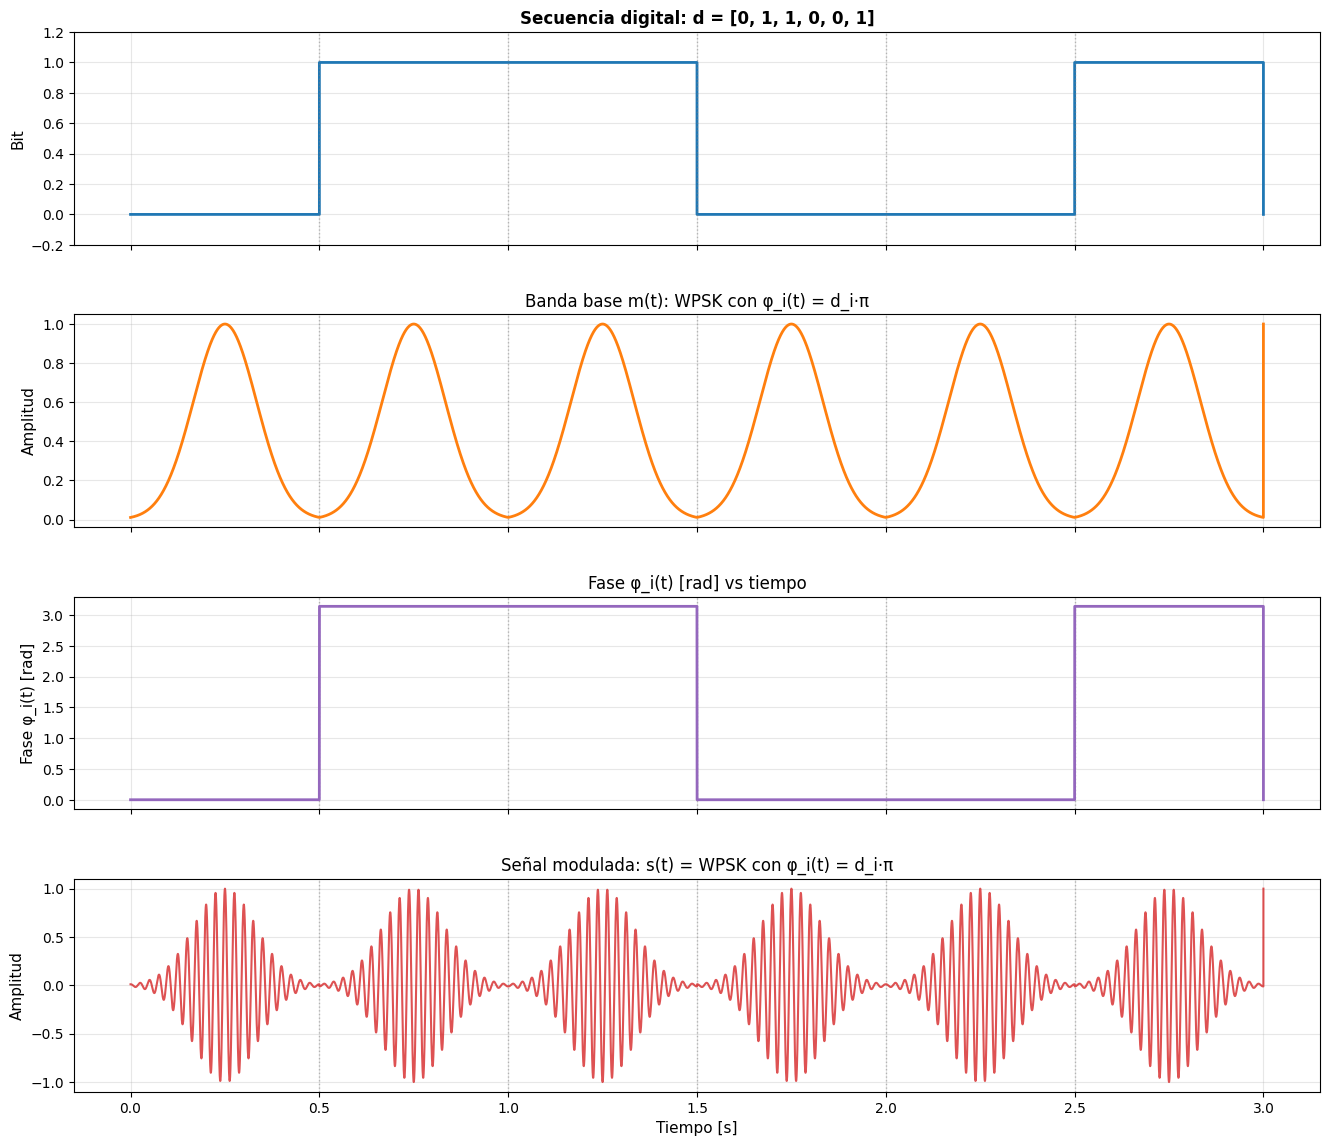

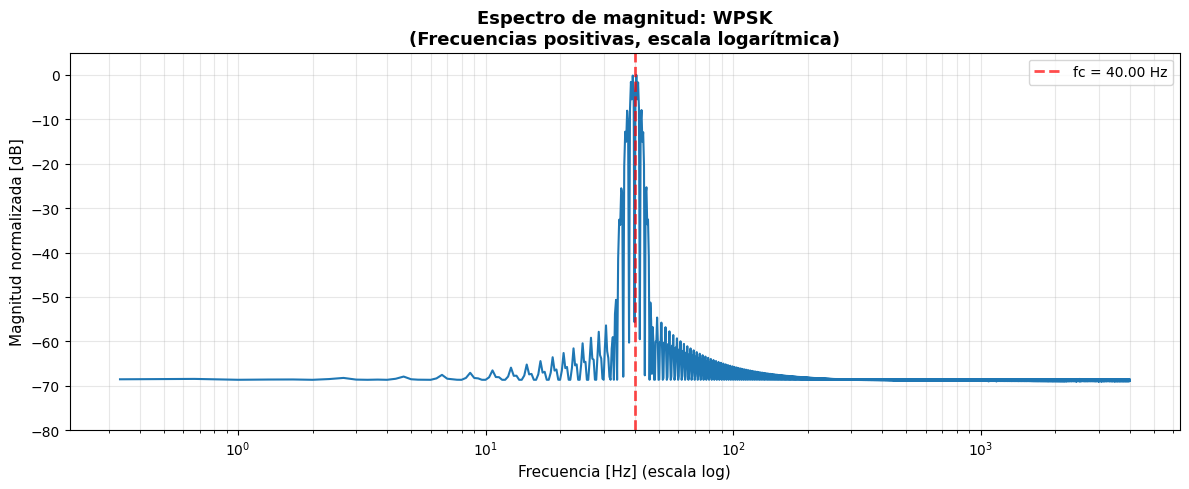


[4/4] Generando señal WFSK (modulación de frecuencia continua)...


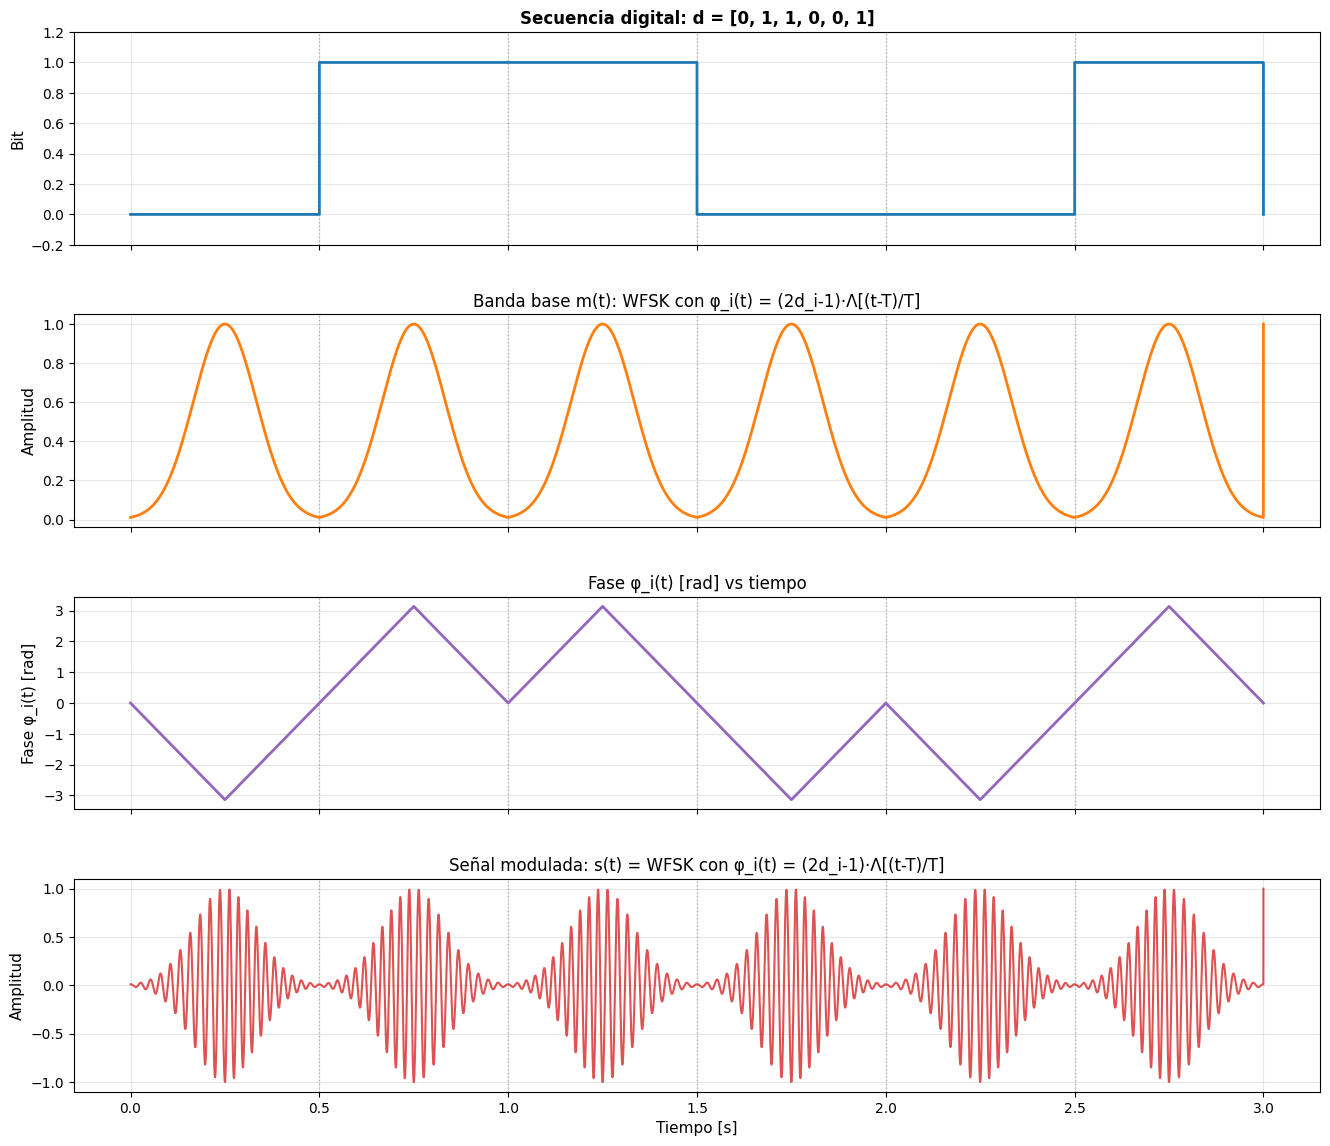

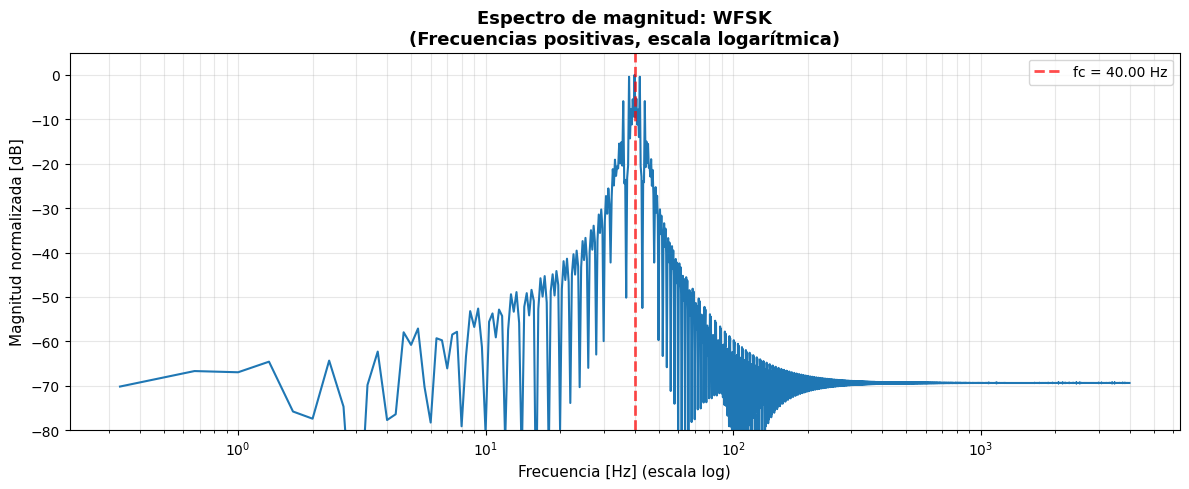


2. ANÁLISIS COMPARATIVO


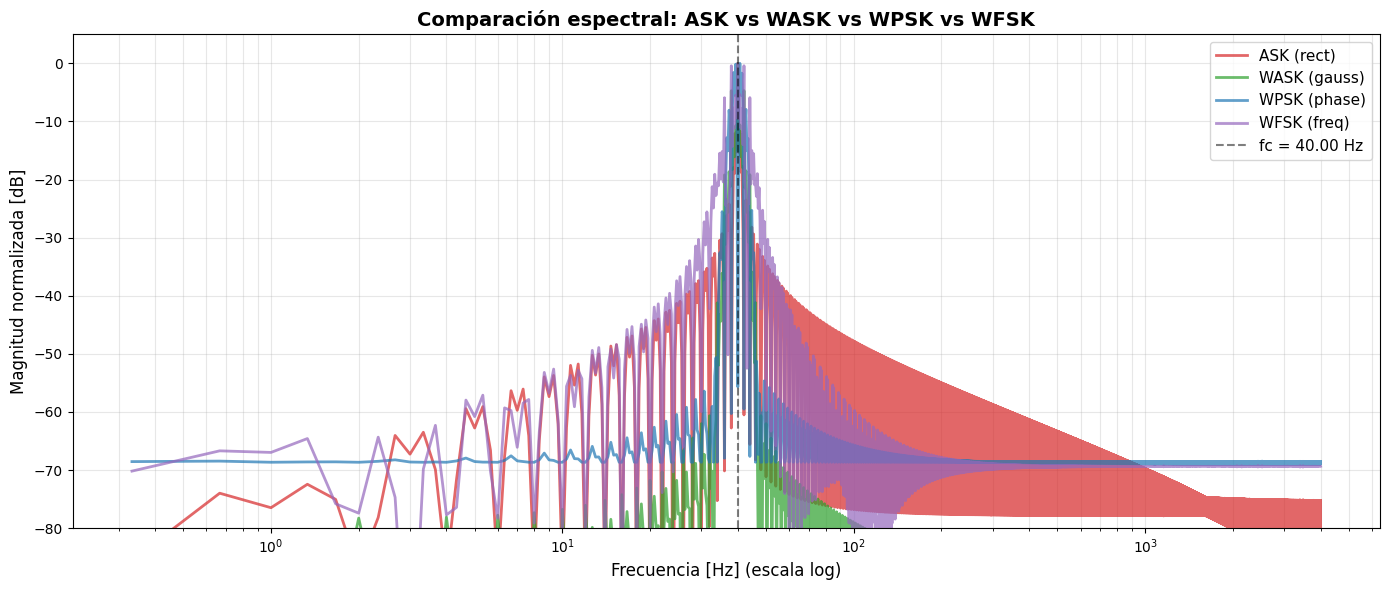


3. MÉTRICAS DE SEÑAL

ASK (rect):
  - Potencia promedio: 0.272470
  - Ancho de banda (-3dB): 0.00 Hz
  - Eficiencia espectral: inf bits/s/Hz

WASK (gauss):
  - Potencia promedio: 0.080494
  - Ancho de banda (-3dB): 0.00 Hz
  - Eficiencia espectral: inf bits/s/Hz

WPSK (phase):
  - Potencia promedio: 0.147737
  - Ancho de banda (-3dB): 2.67 Hz
  - Eficiencia espectral: 0.7500 bits/s/Hz

WFSK (freq):
  - Potencia promedio: 0.147737
  - Ancho de banda (-3dB): 4.00 Hz
  - Eficiencia espectral: 0.5000 bits/s/Hz

ANÁLISIS COMPLETADO


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CLASE PRINCIPAL: Sistema de Modulaciones Digitales
# ============================================================================
class DigitalModulationSystem:
    """
    Sistema completo de modulaciones digitales que implementa:
    - ASK (Amplitude Shift Keying) con pulsos rectangulares
    - WASK (Waveform ASK) con pulsos gaussianos
    - WPSK (Waveform PSK) con modulación de fase
    - WFSK (Waveform FSK) con modulación de frecuencia

    Parámetros matemáticos:
    - v_i(t) = rect_T(t) para ASK (función rectangular)
    - v_i(t) = gauss_T(t) para WASK (función gaussiana)
    - φ_i(t) = d_i·π para WPSK (fase discreta)
    - φ_i(t) = (2d_i - 1)·Λ[(t-T)/T] para WFSK (fase triangular)
    """

    def __init__(self,
                 fs: int = 8000,           # Frecuencia de muestreo [Hz]
                 T_total: float = 3.0,     # Duración total [s]
                 fc_multiplier: int = 20,  # Multiplicador de frecuencia portadora
                 a0: float = 0.3,          # Amplitud para bit 0
                 a1: float = 1.0,          # Amplitud para bit 1
                 device: str = 'cpu'):     # Dispositivo PyTorch
        """
        Constructor del sistema de modulación digital.

        Args:
            fs: Frecuencia de muestreo en Hz (debe ser suficientemente alta)
            T_total: Duración total de la señal en segundos
            fc_multiplier: Factor multiplicativo para fc = fc_multiplier * Rb
            a0, a1: Amplitudes para mapeo binario {0→a0, 1→a1}
            device: 'cpu' o 'cuda' para cómputo en GPU
        """
        self.device = torch.device(device)
        self.fs = fs
        self.T_total = T_total
        self.fc_multiplier = fc_multiplier
        self.a0 = a0
        self.a1 = a1

        # Parámetros derivados (se calculan al establecer los bits)
        self.d = None
        self.N_bits = None
        self.Tb = None
        self.Rb = None
        self.fc = None
        self.t = None
        self.n_samples = None

    def set_bit_sequence(self, d: List[int]):
        """
        Establece la secuencia de bits y calcula parámetros derivados.

        Args:
            d: Lista de bits binarios d_i ∈ {0,1}

        Cálculos:
            - N_bits: Longitud de la secuencia
            - Tb: Período de bit = T_total / N_bits
            - Rb: Tasa de bits = 1 / Tb
            - fc: Frecuencia portadora = fc_multiplier * Rb
            - t: Vector temporal de muestreo
        """
        self.d = torch.tensor(d, dtype=torch.float32, device=self.device)
        self.N_bits = len(d)
        self.Tb = self.T_total / self.N_bits
        self.Rb = 1.0 / self.Tb
        self.fc = self.fc_multiplier * self.Rb

        # Vector temporal: muestreo uniforme en [0, T_total)
        self.n_samples = int(self.fs * self.T_total)
        self.t = torch.linspace(0, self.T_total, self.n_samples,
                                device=self.device)

        print(f"[INFO] Parámetros del sistema:")
        print(f"  - Bits: {d}")
        print(f"  - N_bits: {self.N_bits}")
        print(f"  - Tb: {self.Tb:.4f} s")
        print(f"  - Rb: {self.Rb:.2f} bits/s")
        print(f"  - fc: {self.fc:.2f} Hz")
        print(f"  - fs: {self.fs} Hz")
        print(f"  - Muestras: {self.n_samples}")

    def _generate_pulse_train(self, pulse_type: str = 'rect') -> torch.Tensor:
        """
        Genera el tren de pulsos en banda base m(t).

        Args:
            pulse_type: 'rect' para rectangular, 'gauss' para gaussiano

        Returns:
            m(t): Señal en banda base con amplitudes {a0, a1}

        Matemática:
            Para ASK:  v_i(t) = rect_T(t) = 1 para t ∈ [0, T], 0 en otro caso
            Para WASK: v_i(t) = gauss_T(t) = exp(-0.5·((t-T/2)/(σ))²)
                       donde σ = T/6 (3σ ≈ T para contener >99.7% de energía)
        """
        m = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            # Mapeo digital: d_i → a_i
            amp = self.a1 if self.d[i] == 1 else self.a0

            # Ventana temporal para el bit i
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)

            if pulse_type == 'rect':
                # Pulso rectangular: amplitud constante en [t_start, t_end)
                m[mask] = amp

            elif pulse_type == 'gauss':
                # Pulso gaussiano centrado en el intervalo del bit
                t_center = (t_start + t_end) / 2
                sigma = self.Tb / 6  # Desviación estándar (3σ ≈ Tb)
                t_local = self.t[mask]
                # Gaussiana normalizada a amplitud máxima = amp
                m[mask] = amp * torch.exp(-0.5 * ((t_local - t_center) / sigma) ** 2)

        return m

    def generate_ask(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Genera señal ASK (Amplitude Shift Keying) con pulsos rectangulares.

        Ecuación: s_ASK(t) = a_i · v_i(t) · cos(2π·fc·t)
        donde:
            - a_i ∈ {a0, a1} según d_i
            - v_i(t) = rect_T(t)
            - φ_i(t) = 0 para todo i (sin modulación de fase)

        Returns:
            (m, carrier, s_ask): Banda base, portadora, señal modulada
        """
        # Banda base con pulsos rectangulares
        m = self._generate_pulse_train('rect')

        # Portadora: cos(2π·fc·t)
        carrier = torch.cos(2 * np.pi * self.fc * self.t)

        # Modulación ASK: producto m(t) · cos(2π·fc·t)
        s_ask = m * carrier

        return m, carrier, s_ask

    def generate_wask(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Genera señal WASK (Waveform ASK) con pulsos gaussianos.

        Ecuación: s_WASK(t) = a_i · gauss_T(t) · cos(2π·fc·t)
        donde:
            - v_i(t) = exp(-0.5·((t-T/2)/σ)²) con σ = T/6
            - Ventaja: menor ancho de banda espectral (suavización)

        Returns:
            (m, carrier, s_wask): Banda base gaussiana, portadora, señal modulada
        """
        # Banda base con pulsos gaussianos
        m = self._generate_pulse_train('gauss')

        # Portadora (misma que ASK)
        carrier = torch.cos(2 * np.pi * self.fc * self.t)

        # Modulación WASK
        s_wask = m * carrier

        return m, carrier, s_wask

    def generate_wpsk(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Genera señal WPSK (Waveform PSK) con modulación de fase binaria.

        Ecuación: s_WPSK(t) = A · gauss_T(t) · cos(2π·fc·t + φ_i)
        donde:
            - φ_i(t) = d_i · π (fase constante por bit)
            - d_i = 0 → φ = 0 (fase 0°)
            - d_i = 1 → φ = π (fase 180°, inversión de fase)
            - A = a1 (amplitud constante para energía constante)

        Returns:
            (m, phase, s_wpsk): Envolvente, fase, señal modulada
        """
        # Envolvente gaussiana con amplitud constante a1
        m = torch.ones_like(self.t) * self.a1
        phase = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)

            # Aplicar envolvente gaussiana
            t_center = (t_start + t_end) / 2
            sigma = self.Tb / 6
            t_local = self.t[mask]
            m[mask] = self.a1 * torch.exp(-0.5 * ((t_local - t_center) / sigma) ** 2)

            # Fase binaria: φ_i = d_i · π
            phase[mask] = self.d[i] * np.pi

        # Modulación WPSK: A · cos(2π·fc·t + φ_i)
        s_wpsk = m * torch.cos(2 * np.pi * self.fc * self.t + phase)

        return m, phase, s_wpsk

    def generate_wfsk(self, delta_f: float = None) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Genera señal WFSK (Waveform FSK) con modulación de frecuencia continua.

        Ecuación: s_WFSK(t) = A · gauss_T(t) · cos(2π·fc·t + φ_i(t))
        donde:
            - φ_i(t) = (2d_i - 1) · Λ[(t-iT)/T]
            - Λ(x) = función triangular: 1 - |x| para |x| ≤ 1, 0 en otro caso
            - d_i = 0 → φ decrece linealmente (frecuencia instantánea menor)
            - d_i = 1 → φ crece linealmente (frecuencia instantánea mayor)

        Args:
            delta_f: Desviación de frecuencia [Hz]. Si None, usa Rb/2

        Returns:
            (m, phase, s_wfsk): Envolvente, fase instantánea, señal modulada
        """
        if delta_f is None:
            delta_f = self.Rb / 2  # Índice de modulación h = 0.5

        # Envolvente gaussiana
        m = torch.ones_like(self.t) * self.a1
        phase = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)

            # Envolvente gaussiana
            t_center = (t_start + t_end) / 2
            sigma = self.Tb / 6
            t_local = self.t[mask]
            m[mask] = self.a1 * torch.exp(-0.5 * ((t_local - t_center) / sigma) ** 2)

            # Fase triangular: φ_i(t) = (2d_i - 1) · Λ[(t - t_start)/Tb]
            # Λ(x) implementado como rampa simétrica
            t_norm = (t_local - t_start) / self.Tb  # Normalizar a [0, 1]

            # Función triangular: sube hasta 0.5, luego baja
            lambda_func = torch.where(t_norm <= 0.5,
                                       2 * t_norm,           # Rampa ascendente
                                       2 * (1 - t_norm))     # Rampa descendente

            # Escalar por (2d_i - 1) y amplitud de fase
            phase[mask] = (2 * self.d[i] - 1) * 2 * np.pi * delta_f * self.Tb * lambda_func

        # Modulación WFSK
        s_wfsk = m * torch.cos(2 * np.pi * self.fc * self.t + phase)

        return m, phase, s_wfsk

    def compute_spectrum(self, signal: torch.Tensor) -> Tuple[np.ndarray, np.ndarray]:
        """
        Calcula el espectro de magnitud de una señal (solo frecuencias positivas).

        Args:
            signal: Señal temporal s(t)

        Returns:
            (freqs, magnitude_db): Frecuencias [Hz] y magnitud normalizada [dB]

        Procesamiento:
            1. FFT: S(f) = FFT{s(t)}
            2. Selección de f > 0
            3. Normalización: |S(f)| / max(|S(f)|)
            4. Conversión a dB: 20·log₁₀(|S(f)|)
        """
        # Convertir a numpy para FFT (más rápido que torch.fft para este caso)
        signal_np = signal.cpu().numpy()

        # FFT y vector de frecuencias
        S = np.fft.fft(signal_np)
        freqs = np.fft.fftfreq(len(signal_np), d=1/self.fs)

        # Solo frecuencias positivas
        mask_pos = freqs > 0
        freqs_pos = freqs[mask_pos]
        S_pos = np.abs(S[mask_pos])

        # Normalización y conversión a dB
        S_pos_norm = S_pos / (S_pos.max() + 1e-12)  # Evitar división por cero
        S_pos_db = 20 * np.log10(S_pos_norm + 1e-12)  # Evitar log(0)

        return freqs_pos, S_pos_db


# ============================================================================
# FUNCIONES DE VISUALIZACIÓN
# ============================================================================
def plot_time_domain(system: DigitalModulationSystem,
                     m: torch.Tensor,
                     s: torch.Tensor,
                     title: str,
                     additional_signal: torch.Tensor = None,
                     additional_label: str = ""):
    """
    Visualiza señales en el dominio temporal.

    Args:
        system: Sistema de modulación
        m: Señal en banda base
        s: Señal modulada
        title: Título del esquema de modulación
        additional_signal: Señal adicional (e.g., fase)
        additional_label: Etiqueta para señal adicional
    """
    t_np = system.t.cpu().numpy()
    m_np = m.cpu().numpy()
    s_np = s.cpu().numpy()
    d_np = system.d.cpu().numpy()

    # Crear tren de bits para referencia
    bit_wave = np.zeros_like(t_np)
    for i, bit in enumerate(d_np):
        t_start = i * system.Tb
        t_end = (i + 1) * system.Tb
        mask = (t_np >= t_start) & (t_np < t_end)
        bit_wave[mask] = bit

    # Configurar subplots
    n_plots = 4 if additional_signal is not None else 3
    fig, axs = plt.subplots(n_plots, 1, figsize=(14, 3*n_plots), sharex=True)
    fig.tight_layout(pad=4)

    # 1. Secuencia de bits
    axs[0].step(t_np, bit_wave, where='post', linewidth=2, color='tab:blue')
    axs[0].set_ylim(-0.2, 1.2)
    axs[0].set_ylabel("Bit", fontsize=11)
    axs[0].set_title(f"Secuencia digital: d = {system.d.cpu().numpy().astype(int).tolist()}",
                     fontsize=12, fontweight='bold')
    axs[0].grid(True, alpha=0.3)

    # Líneas verticales de separación de bits
    for k in range(1, system.N_bits):
        for ax in axs:
            ax.axvline(k * system.Tb, color='gray', ls=':', lw=1, alpha=0.5)

    # 2. Banda base
    axs[1].plot(t_np, m_np, linewidth=2, color='tab:orange')
    axs[1].set_ylabel("Amplitud", fontsize=11)
    axs[1].set_title(f"Banda base m(t): {title}", fontsize=12)
    axs[1].grid(True, alpha=0.3)

    # 3. Señal adicional (fase para PSK/FSK)
    if additional_signal is not None:
        add_np = additional_signal.cpu().numpy()
        axs[2].plot(t_np, add_np, linewidth=2, color='tab:purple')
        axs[2].set_ylabel(additional_label, fontsize=11)
        axs[2].set_title(f"{additional_label} vs tiempo", fontsize=12)
        axs[2].grid(True, alpha=0.3)

    # 4. Señal modulada
    axs[-1].plot(t_np, s_np, linewidth=1.5, color='tab:red', alpha=0.8)
    axs[-1].set_ylabel("Amplitud", fontsize=11)
    axs[-1].set_xlabel("Tiempo [s]", fontsize=11)
    axs[-1].set_title(f"Señal modulada: s(t) = {title}", fontsize=12)
    axs[-1].grid(True, alpha=0.3)

    plt.show()


def plot_spectrum(freqs: np.ndarray,
                  magnitude_db: np.ndarray,
                  title: str,
                  fc: float):
    """
    Visualiza el espectro de magnitud en escala logarítmica.

    Args:
        freqs: Vector de frecuencias positivas [Hz]
        magnitude_db: Magnitud normalizada en dB
        title: Título del esquema de modulación
        fc: Frecuencia portadora [Hz] (para referencia visual)
    """
    plt.figure(figsize=(12, 5))
    plt.semilogx(freqs, magnitude_db, linewidth=1.5, color='tab:blue')
    plt.axvline(fc, color='red', linestyle='--', linewidth=2,
                label=f'fc = {fc:.2f} Hz', alpha=0.7)
    plt.title(f"Espectro de magnitud: {title}\n(Frecuencias positivas, escala logarítmica)",
              fontsize=13, fontweight='bold')
    plt.xlabel("Frecuencia [Hz] (escala log)", fontsize=11)
    plt.ylabel("Magnitud normalizada [dB]", fontsize=11)
    plt.grid(True, which='both', alpha=0.3)
    plt.legend(fontsize=10)
    plt.ylim([-80, 5])  # Rango típico para visualización en dB
    plt.tight_layout()
    plt.show()


def plot_comparative_spectra(system: DigitalModulationSystem,
                              signals: dict):
    """
    Compara espectros de diferentes esquemas de modulación.

    Args:
        system: Sistema de modulación
        signals: Diccionario {'nombre': señal_tensor}
    """
    plt.figure(figsize=(14, 6))

    colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:purple']

    for i, (name, signal) in enumerate(signals.items()):
        freqs, mag_db = system.compute_spectrum(signal)
        plt.semilogx(freqs, mag_db, linewidth=2,
                     label=name, color=colors[i % len(colors)], alpha=0.7)

    plt.axvline(system.fc, color='black', linestyle='--', linewidth=1.5,
                label=f'fc = {system.fc:.2f} Hz', alpha=0.5)
    plt.title("Comparación espectral: ASK vs WASK vs WPSK vs WFSK",
              fontsize=14, fontweight='bold')
    plt.xlabel("Frecuencia [Hz] (escala log)", fontsize=12)
    plt.ylabel("Magnitud normalizada [dB]", fontsize=12)
    plt.grid(True, which='both', alpha=0.3)
    plt.legend(fontsize=11, loc='upper right')
    plt.ylim([-80, 5])
    plt.tight_layout()
    plt.show()


# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================
if __name__ == "__main__":
    print("="*70)
    print("SISTEMA DE MODULACIONES DIGITALES")
    print("Implementación en PyTorch - Teoría de Señales")
    print("="*70 + "\n")

    # ------------------------------------------------------------------------
    # Configuración del sistema
    # ------------------------------------------------------------------------
    system = DigitalModulationSystem(
        fs=8000,              # Frecuencia de muestreo [Hz]
        T_total=3.0,          # Duración total [s]
        fc_multiplier=20,     # fc = 20·Rb
        a0=0.3,               # Amplitud para bit 0
        a1=1.0,               # Amplitud para bit 1
        device='cpu'          # Usar 'cuda' si hay GPU disponible
    )

    # Secuencia de bits: d = [0,1,1,0,0,1]
    d = [0, 1, 1, 0, 0, 1]
    system.set_bit_sequence(d)

    print("\n" + "="*70)
    print("1. GENERACIÓN DE SEÑALES")
    print("="*70)

    # ------------------------------------------------------------------------
    # ASK: Amplitude Shift Keying
    # ------------------------------------------------------------------------
    print("\n[1/4] Generando señal ASK (pulsos rectangulares)...")
    m_ask, carrier_ask, s_ask = system.generate_ask()
    freqs_ask, mag_ask = system.compute_spectrum(s_ask)

    plot_time_domain(system, m_ask, s_ask,
                     "ASK con v_i(t) = rect_T(t), φ_i = 0")
    plot_spectrum(freqs_ask, mag_ask, "ASK", system.fc)

    # ------------------------------------------------------------------------
    # WASK: Waveform ASK
    # ------------------------------------------------------------------------
    print("\n[2/4] Generando señal WASK (pulsos gaussianos)...")
    m_wask, carrier_wask, s_wask = system.generate_wask()
    freqs_wask, mag_wask = system.compute_spectrum(s_wask)

    plot_time_domain(system, m_wask, s_wask,
                     "WASK con v_i(t) = gauss_T(t)")
    plot_spectrum(freqs_wask, mag_wask, "WASK", system.fc)

    # ------------------------------------------------------------------------
    # WPSK: Waveform PSK
    # ------------------------------------------------------------------------
    print("\n[3/4] Generando señal WPSK (modulación de fase binaria)...")
    m_wpsk, phase_wpsk, s_wpsk = system.generate_wpsk()
    freqs_wpsk, mag_wpsk = system.compute_spectrum(s_wpsk)

    plot_time_domain(system, m_wpsk, s_wpsk,
                     "WPSK con φ_i(t) = d_i·π",
                     additional_signal=phase_wpsk,
                     additional_label="Fase φ_i(t) [rad]")
    plot_spectrum(freqs_wpsk, mag_wpsk, "WPSK", system.fc)

    # ------------------------------------------------------------------------
    # WFSK: Waveform FSK
    # ------------------------------------------------------------------------
    print("\n[4/4] Generando señal WFSK (modulación de frecuencia continua)...")
    m_wfsk, phase_wfsk, s_wfsk = system.generate_wfsk()
    freqs_wfsk, mag_wfsk = system.compute_spectrum(s_wfsk)

    plot_time_domain(system, m_wfsk, s_wfsk,
                     "WFSK con φ_i(t) = (2d_i-1)·Λ[(t-T)/T]",
                     additional_signal=phase_wfsk,
                     additional_label="Fase φ_i(t) [rad]")
    plot_spectrum(freqs_wfsk, mag_wfsk, "WFSK", system.fc)

    # ------------------------------------------------------------------------
    # Comparación espectral
    # ------------------------------------------------------------------------
    print("\n" + "="*70)
    print("2. ANÁLISIS COMPARATIVO")
    print("="*70)

    signals_dict = {
        'ASK (rect)': s_ask,
        'WASK (gauss)': s_wask,
        'WPSK (phase)': s_wpsk,
        'WFSK (freq)': s_wfsk
    }

    plot_comparative_spectra(system, signals_dict)

    # ------------------------------------------------------------------------
    # Métricas de señal
    # ------------------------------------------------------------------------
    print("\n" + "="*70)
    print("3. MÉTRICAS DE SEÑAL")
    print("="*70)

    for name, signal in signals_dict.items():
        # Potencia promedio: P = (1/T) ∫|s(t)|² dt
        power = torch.mean(signal ** 2).item()

        # Ancho de banda a -3dB (aproximado)
        freqs, mag_db = system.compute_spectrum(signal)
        bw_mask = mag_db > (mag_db.max() - 3)
        bandwidth = freqs[bw_mask].max() - freqs[bw_mask].min()

        print(f"\n{name}:")
        print(f"  - Potencia promedio: {power:.6f}")
        print(f"  - Ancho de banda (-3dB): {bandwidth:.2f} Hz")
        print(f"  - Eficiencia espectral: {system.Rb/bandwidth:.4f} bits/s/Hz")

    print("\n" + "="*70)
    print("ANÁLISIS COMPLETADO")
    print("="*70)

Parámetros de generación:
Bits Id': [0, 1, 1, 0, 0, 1]
Tb = 0.05s, Fs = 20000Hz, fc = 2000Hz, f_dev = 300Hz, Ns = 1000 muestras/símbolo
Mapeo d->a: 0 -> 0.5, 1 -> 1.0



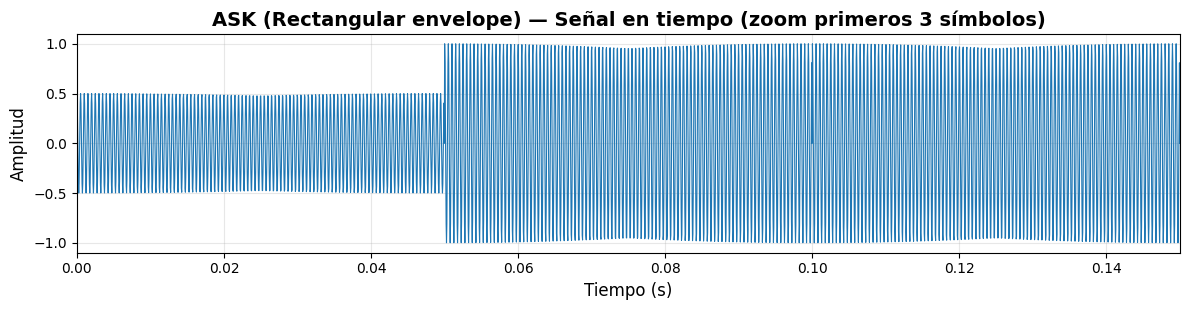

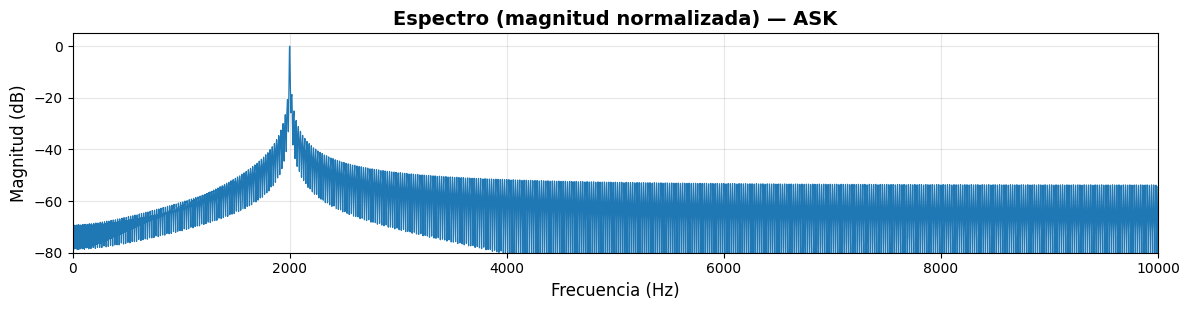

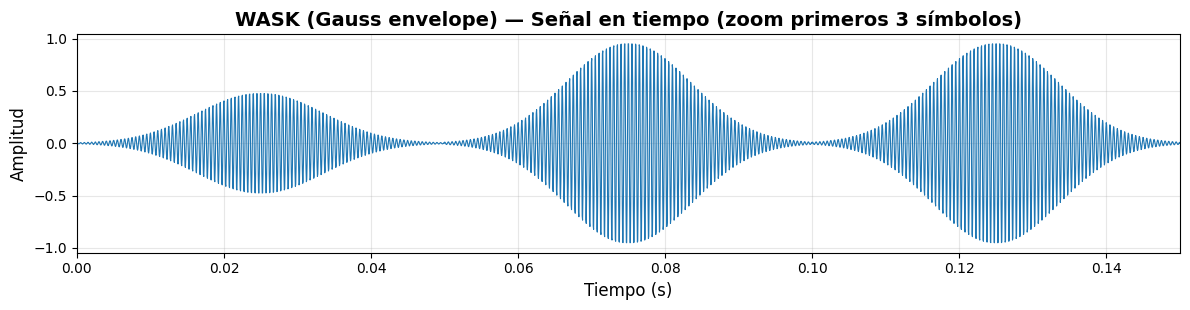

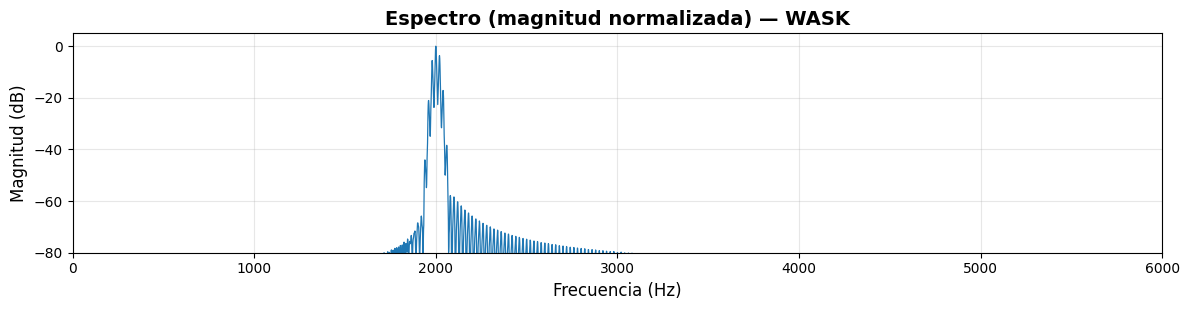

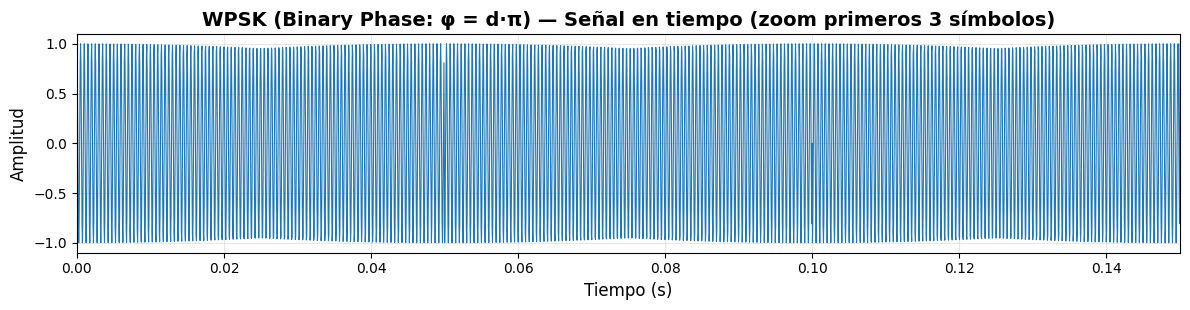

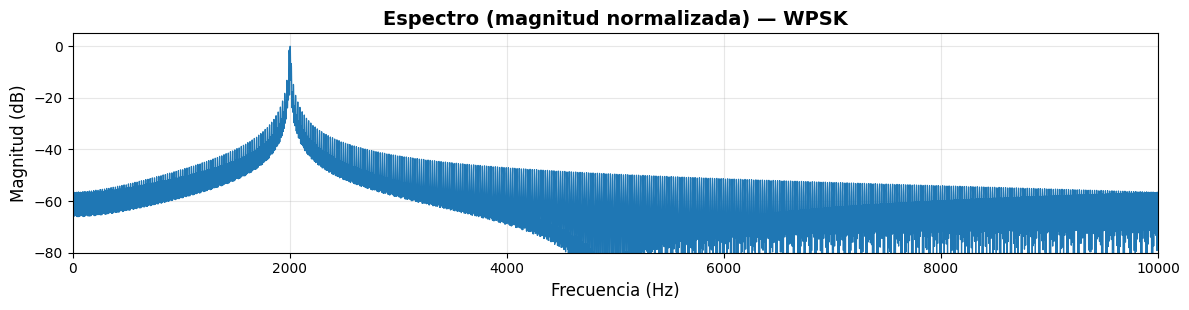

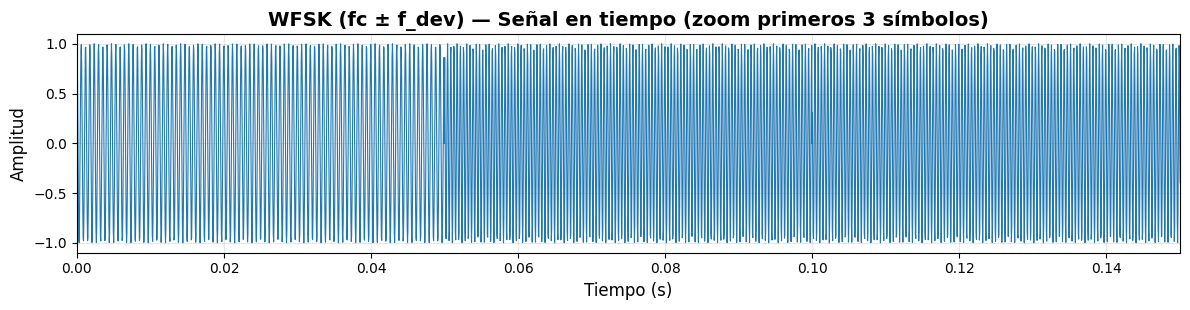

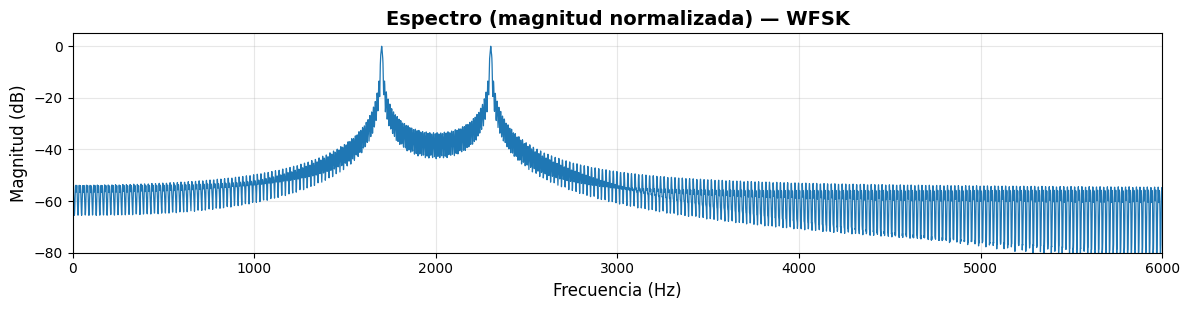

Decisiones (demodulación):
Original bits : [0 1 1 0 0 1]
ASK  (env)    : [0 1 1 0 0 1]
WPSK (coherent): [0 1 1 0 0 1]
WFSK (coherent): [0 1 1 1 1 0]

BER aproximado (sin ruido):
ASK  BER : 1.0
WPSK BER : 1.0
WFSK BER : 1.0


In [2]:
# ============================
# MODULACIONES: ASK, WASK, WPSK, WFSK (PyTorch)
# ============================

# --- IMPORTS ---
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window
from math import pi

# Detectar dispositivo (CPU es suficiente para estas señales)
device = torch.device("cpu")

# ----------------------------
# 0) PARÁMETROS GENERALES (ajustables)
# ----------------------------
bits = torch.tensor([0,1,1,0,0,1], dtype=torch.int64)  # Id' solicitado
Tb = 0.05          # duración de símbolo [s]
Fs = 20000         # frecuencia de muestreo [Hz]
fc = 2000          # frecuencia portadora [Hz]
f_dev = 300        # desviación para FSK [Hz]
a0, a1 = 0.5, 1.0  # amplitudes > 0 (mapeo d->a)
sigma_frac = 1/6   # sigma = Tb * sigma_frac para la gaussiana
continuous_phase_fsk = True  # mantener fase continua en FSK

# Constantes
Ts = 1.0/Fs
Ns = int(round(Tb * Fs))  # muestras por símbolo
T_total = Tb * bits.shape[0]
N_total = Ns * bits.shape[0]  # total muestras
t_sym = torch.linspace(0, Tb, steps=Ns, dtype=torch.float32, device=device, requires_grad=False)
t_total = torch.linspace(0, T_total, steps=N_total, dtype=torch.float32, device=device, requires_grad=False)

# ----------------------------
# 1) Funciones de pulso (envolventes)
# ----------------------------
# Rectangular: v_i(t) = rect_T(t)
def rect_pulse(t, T):
    # rect(t) on [0, T)
    return ((t >= 0.0) & (t < T)).to(dtype=torch.float32)

# Gaussian pulse truncada en [0,T)
def gauss_pulse(t, T, sigma_frac=1/6):
    mu = T/2.0
    sigma = T * sigma_frac
    g = torch.exp(-0.5 * ((t - mu)/sigma)**2)
    return g * rect_pulse(t, T)

# ----------------------------
# 2) Utilidades: mapeos y portadora
# ----------------------------
def map_amplitude(d):
    # mapeo d->a
    return a1 if d==1 else a0

def carrier_cos(t, fc, phase=0.0):
    # cos(2π f_c t + phase)
    return torch.cos(2*pi*fc*t + phase)

# ----------------------------
# 3) Generadores de señal (PyTorch tensors)
# Formulación matemática incluida antes de cada función.
# ----------------------------

# 3.1 ASK (Amplitude Shift Keying)
# s(t) = a_i * v_i(t) * cos(2π f_c t + φ_i(t))
# Condición: v_i(t)=rect_T(t), φ_i(t)=0
def gen_ASK(bits, t_sym):
    s = torch.zeros(N_total, dtype=torch.float32, device=device)
    for i, d in enumerate(bits.tolist()):
        a = map_amplitude(d)
        v = rect_pulse(t_sym, Tb)             # v_i(t)
        start = i*Ns
        end   = start + Ns
        s[start:end] = a * v * carrier_cos(t_sym, fc, phase=0.0)
    return s

# 3.2 WASK (Weighted ASK con envolvente Gaussiana)
# s(t) = a_i * Gauss_T(t) * cos(2π f_c t)
def gen_WASK(bits, t_sym):
    s = torch.zeros(N_total, dtype=torch.float32, device=device)
    for i, d in enumerate(bits.tolist()):
        a = map_amplitude(d)
        v = gauss_pulse(t_sym, Tb, sigma_frac=sigma_frac)
        start = i*Ns; end = start + Ns
        s[start:end] = a * v * carrier_cos(t_sym, fc, phase=0.0)
    return s

# 3.3 WPSK (Binary Phase Shift Keying with φ_i = d_i * π)
# s(t) = v_i(t) * cos(2π f_c t + d_i * π)
def gen_WPSK(bits, t_sym):
    s = torch.zeros(N_total, dtype=torch.float32, device=device)
    for i, d in enumerate(bits.tolist()):
        phi = float(d) * pi
        v = rect_pulse(t_sym, Tb)
        start = i*Ns; end = start + Ns
        s[start:end] = v * carrier_cos(t_sym, fc, phase=phi)
    return s

# 3.4 WFSK (Binary Frequency Shift Keying)
# f_i = f_c + (2 d_i - 1) * f_dev
# s(t) = v_i(t) * cos( 2π ∫ f_i(t) dt + φ0 ) ; implementamos por símbolo.
def gen_WFSK(bits, t_sym, continuous_phase=True):
    s = torch.zeros(N_total, dtype=torch.float32, device=device)
    phase = 0.0
    for i, d in enumerate(bits.tolist()):
        f_i = fc + (2*d - 1) * f_dev
        # phase segment: 2π f_i t + phase
        # t_sym goes from 0..Tb but when concatenated we preserve phase continuity if desired
        if continuous_phase:
            # usar fase inicial 'phase'
            seg_phase = 2*pi*f_i*t_sym + phase
            # actualizar phase para el siguiente símbolo (fase final del segmento)
            phase = float(seg_phase[-1] + 2*pi*f_i*(1.0/Fs))
            carrier = torch.cos(seg_phase)
        else:
            carrier = torch.cos(2*pi*f_i*t_sym)
        start = i*Ns; end = start + Ns
        s[start:end] = rect_pulse(t_sym, Tb) * carrier
    return s

# ----------------------------
# 4) Generar las señales
# ----------------------------
s_ASK = gen_ASK(bits, t_sym)
s_WASK = gen_WASK(bits, t_sym)
s_WPSK = gen_WPSK(bits, t_sym)
s_WFSK = gen_WFSK(bits, t_sym, continuous_phase=continuous_phase_fsk)

# ----------------------------
# 5) Funciones de análisis: espectro (usando torch.fft), y visualización profesional
# ----------------------------
def torch_fft_spectrum(sig, Fs, n_fft=2**14):
    # usa ventana hann para suavizar leakage
    win = torch.hann_window(len(sig), periodic=False, dtype=torch.float32, device=device)
    X = torch.fft.fft(sig * win, n=n_fft)
    f = torch.fft.fftfreq(n_fft, d=1.0/Fs)
    pos = f >= 0
    mag = torch.abs(X)
    # normalizar
    mag = mag / (torch.max(mag) + 1e-12)
    return f[pos].cpu().numpy(), 20.0 * torch.log10(mag[pos] + 1e-12).cpu().numpy()

# Plot profesional (tiempo y espectro)
def plot_time(signal, t_total, title, zoom_symbols=3):
    plt.figure(figsize=(12,3.2))
    plt.plot(t_total.cpu().numpy(), signal.cpu().numpy(), linewidth=0.8)
    plt.title(title, fontsize=14, fontweight='semibold')
    plt.xlabel("Tiempo (s)", fontsize=12)
    plt.ylabel("Amplitud", fontsize=12)
    plt.grid(alpha=0.3)
    plt.xlim(0, zoom_symbols*Tb)
    plt.tight_layout()
    plt.show()

def plot_spectrum(signal, Fs, title, n_fft=2**14, fmax=None):
    f, mag_db = torch_fft_spectrum(signal, Fs, n_fft=n_fft)
    plt.figure(figsize=(12,3.2))
    plt.plot(f, mag_db, linewidth=0.9)
    plt.title(f"Espectro (magnitud normalizada) — {title}", fontsize=14, fontweight='semibold')
    plt.xlabel("Frecuencia (Hz)", fontsize=12)
    plt.ylabel("Magnitud (dB)", fontsize=12)
    plt.grid(alpha=0.3)
    plt.xlim(0, fmax if fmax is not None else Fs/2)
    plt.ylim(-80, 5)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 6) Visualización final (presentación)
# ----------------------------
print("Parámetros de generación:")
print(f"Bits Id': {bits.tolist()}")
print(f"Tb = {Tb}s, Fs = {Fs}Hz, fc = {fc}Hz, f_dev = {f_dev}Hz, Ns = {Ns} muestras/símbolo")
print(f"Mapeo d->a: 0 -> {a0}, 1 -> {a1}\n")

# Tiempo total (convertir a cpu numpy para plot)
plot_time(s_ASK, t_total, "ASK (Rectangular envelope) — Señal en tiempo (zoom primeros 3 símbolos)")
plot_spectrum(s_ASK, Fs, "ASK", fmax=10000)

plot_time(s_WASK, t_total, "WASK (Gauss envelope) — Señal en tiempo (zoom primeros 3 símbolos)")
plot_spectrum(s_WASK, Fs, "WASK", fmax=6000)  # esencia espectral centrada en fc

plot_time(s_WPSK, t_total, "WPSK (Binary Phase: φ = d·π) — Señal en tiempo (zoom primeros 3 símbolos)")
plot_spectrum(s_WPSK, Fs, "WPSK", fmax=10000)

plot_time(s_WFSK, t_total, "WFSK (fc ± f_dev) — Señal en tiempo (zoom primeros 3 símbolos)")
plot_spectrum(s_WFSK, Fs, "WFSK", fmax=6000)

# ----------------------------
# 7) Demoduladores sencillos (evaluación)
#    - ASK: detector por envolvente + decisión por umbral
#    - WPSK: demodulación coherente por correlación (multiplicar por cos y sin y acumulado -> decisión por signo)
#    - WFSK: correlador simple frente a dos portadoras (coherente)
# Nota: estos demoduladores son didácticos y suficientes para análisis en laboratorio.
# ----------------------------

# Helpers: separar símbolos
def symbol_segments(signal):
    return signal.view(bits.shape[0], Ns)

# ASK demodulación por envolvente
def demod_ASK_envelope(signal):
    segs = symbol_segments(signal)
    # energía/envolvente por símbolo (valores positivos)
    energy = torch.sum(torch.abs(segs), dim=1)
    # Normalizar y decidir por umbral medio
    threshold = 0.5 * (torch.max(energy) + torch.min(energy))
    decisions = (energy > threshold).to(torch.int64)
    return decisions.cpu().numpy(), energy.cpu().numpy()

# WPSK coh demod por correlación con portadora de referencia (cos)
def demod_WPSK_coherent(signal):
    segs = symbol_segments(signal)
    decisions = []
    for i in range(segs.shape[0]):
        # correlador: <s, cos(2πfc t)> y <s, sin(2πfc t)> (coherente)
        ref_cos = torch.cos(2*pi*fc*t_sym).to(device)
        corr = torch.sum(segs[i] * ref_cos)
        # para BPSK con 0->phase 0, 1->phase pi, signo de correlación decide
        decisions.append(0 if corr > 0 else 1)
    return np.array(decisions), None

# WFSK correlación frente a fc-f_dev y fc+f_dev (coherente)
def demod_WFSK_coherent(signal):
    segs = symbol_segments(signal)
    decisions = []
    for i in range(segs.shape[0]):
        ref0 = torch.cos(2*pi*(fc - f_dev)*t_sym).to(device)
        ref1 = torch.cos(2*pi*(fc + f_dev)*t_sym).to(device)
        c0 = torch.sum(segs[i] * ref0)
        c1 = torch.sum(segs[i] * ref1)
        decisions.append(0 if c0 > c1 else 1)
    return np.array(decisions), None

# Ejecutar demoduladores
dec_ask, en = demod_ASK_envelope(s_ASK)
dec_wpsk, _ = demod_WPSK_coherent(s_WPSK)
dec_wfsk, _ = demod_WFSK_coherent(s_WFSK)

print("Decisiones (demodulación):")
print("Original bits :", bits.cpu().numpy())
print("ASK  (env)    :", dec_ask)
print("WPSK (coherent):", dec_wpsk)
print("WFSK (coherent):", dec_wfsk)

# Evaluar errores
def ber(original, decided):
    return np.mean(original.cpu().numpy() != decided)

print("\nBER aproximado (sin ruido):")
print("ASK  BER :", ber(bits, torch.tensor(dec_ask)))
print("WPSK BER :", ber(bits, torch.tensor(dec_wpsk)))
print("WFSK BER :", ber(bits, torch.tensor(dec_wfsk)))

# FIN del notebook


**TALLER # 2**

$V_i(t) = \text{rect}_T (t)$, Para todo $i$, $t \in T$

$\phi_i (t) = d_i \pi$

**BPSK**

***

$\Phi_i (t) = (2d_i - 1)t$

**BFSK**

***

s.t: $W_0 (T) = 2\pi K$, $K \in \mathbb{Z}$

**CPM** -- (minima condicion, ch ortogonal (W2, W1)

***

$r_1 (t) = \text{Gauss}$

**MSK**

***

#Importar liberias

In [3]:
# ===============================================================
# TALLER DE MODULACIONES DIGITALES

# ===============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 10


#Clase del sistema de modulaciones

In [4]:
class DigitalModulationSystem:
    """
    Sistema de modulaciones digitales con:
    --------------------------------------
    1. BPSK: v_i(t) = rect_T(t), φ_i(t) = d_i·π
    2. BFSK: φ_i(t) = (2d_i - 1)·t
    3. CPM:  W₀·T = 2π·k (k entero), ortogonalidad mínima
    4. MSK:  v_i(t) = gauss(t), h = 0.5
    """

    def __init__(self, bits: List[int], fs=20000, fc_mult=20, T_total=3.0):
        self.bits = torch.tensor(bits, dtype=torch.float32)
        self.N = len(bits)
        self.T_total = T_total
        self.fs = fs
        self.Tb = T_total / self.N
        self.Rb = 1 / self.Tb
        self.fc = fc_mult * self.Rb
        self.t = torch.linspace(0, T_total, int(fs * T_total))
        print(f"[Sistema inicializado] Bits={bits}, fc={self.fc:.2f}Hz, Tb={self.Tb:.4f}s")

    # ============================================================
    # BPSK
    # ============================================================
    def BPSK(self):
        """
        Binary Phase Shift Keying:
        v_i(t) = rect_T(t)
        φ_i(t) = d_i·π
        """
        env = torch.zeros_like(self.t)
        phase = torch.zeros_like(self.t)
        for i, d in enumerate(self.bits):
            mask = (self.t >= i * self.Tb) & (self.t < (i + 1) * self.Tb)
            env[mask] = 1.0
            phase[mask] = d * np.pi
        s = env * torch.cos(2 * np.pi * self.fc * self.t + phase)
        return env, phase, s

    # ============================================================
    # BFSK
    # ============================================================
    def BFSK(self):
        """
        Binary Frequency Shift Keying:
        φ_i(t) = (2d_i - 1)·t
        f0 = fc - Δf, f1 = fc + Δf
        """
        Δf = self.Rb
        env = torch.ones_like(self.t)
        phase = torch.zeros_like(self.t)
        for i, d in enumerate(self.bits):
            mask = (self.t >= i * self.Tb) & (self.t < (i + 1) * self.Tb)
            t_local = self.t[mask] - i * self.Tb
            phase[mask] = 2 * np.pi * Δf * (2 * d - 1) * t_local
        s = env * torch.cos(2 * np.pi * self.fc * self.t + phase)
        return env, phase, s

    # ============================================================
    # CPM
    # ============================================================
    def CPM(self, h=0.5, k=1):
        """
        Continuous Phase Modulation:
        Restricción: W₀T = 2πk (k entero)
        Fase continua entre símbolos
        """
        W0 = 2 * np.pi * k / self.Tb
        print(f"[CPM] W₀={W0:.3f} rad/s, W₀T={W0*self.Tb:.3f} ≈ 2π·{k}")
        env = torch.ones_like(self.t)
        phase = torch.zeros_like(self.t)
        symbols = 2 * self.bits - 1
        φ_acc = 0
        for i, s_i in enumerate(symbols):
            mask = (self.t >= i * self.Tb) & (self.t < (i + 1) * self.Tb)
            t_local = self.t[mask] - i * self.Tb
            q_t = t_local / self.Tb
            Δφ = np.pi * h * s_i * q_t
            phase[mask] = φ_acc + Δφ
            φ_acc += np.pi * h * s_i
        s = env * torch.cos(2 * np.pi * self.fc * self.t + phase)
        return env, phase, s

    # ============================================================
    # MSK
    # ============================================================
    def MSK(self):
        """
        Minimum Shift Keying:
        v_i(t) = gauss(t)
        h = 0.5 → mínima separación ortogonal
        """
        env = torch.zeros_like(self.t)
        phase = torch.zeros_like(self.t)
        symbols = 2 * self.bits - 1
        φ_acc = 0
        for i, s_i in enumerate(symbols):
            mask = (self.t >= i * self.Tb) & (self.t < (i + 1) * self.Tb)
            t_local = self.t[mask] - i * self.Tb
            sigma = self.Tb / 6
            env[mask] = torch.exp(-0.5 * ((t_local - self.Tb / 2) / sigma) ** 2)
            q_t = 0.5 * (1 - torch.cos(np.pi * t_local / self.Tb))
            Δφ = (np.pi / 2) * s_i * q_t
            phase[mask] = φ_acc + Δφ
            φ_acc += (np.pi / 2) * s_i
        s = env * torch.cos(2 * np.pi * self.fc * self.t + phase)
        return env, phase, s


# Funciones auxiliares de graficación

In [5]:
def plot_signal(t, s, phase, title):
    """Gráfica de señal y fase."""
    plt.figure(figsize=(12, 4))
    plt.subplot(2, 1, 1)
    plt.plot(t, s, color='tab:red')
    plt.title(f"{title} - Señal s(t)")
    plt.ylabel('Amplitud')
    plt.grid(True, alpha=0.4)

    plt.subplot(2, 1, 2)
    plt.plot(t, phase, color='tab:purple')
    plt.title(f"{title} - Fase φ(t)")
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Fase [rad]')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


#Simulación completa

[Sistema inicializado] Bits=[0, 1, 1, 0, 0, 1], fc=40.00Hz, Tb=0.5000s
[CPM] W₀=12.566 rad/s, W₀T=6.283 ≈ 2π·1


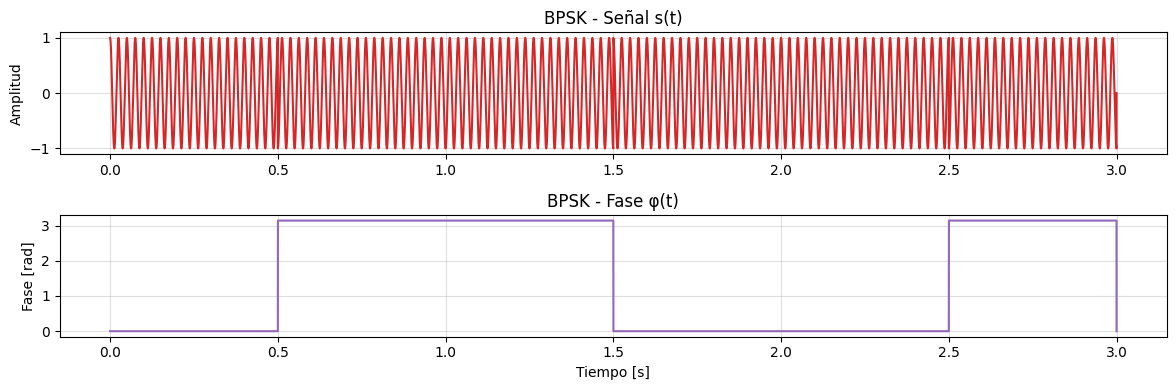

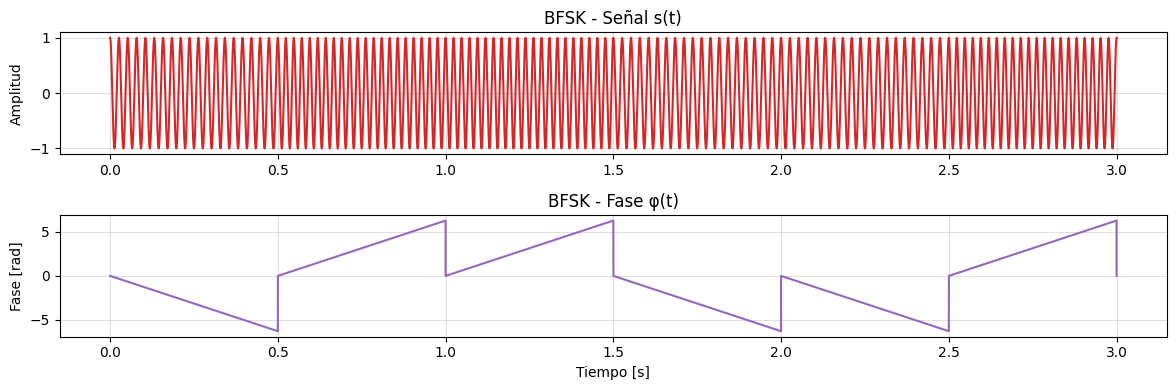

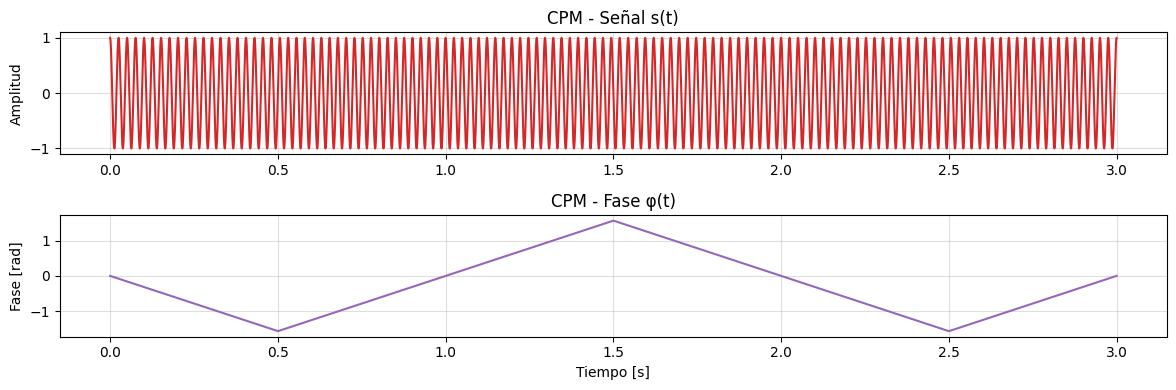

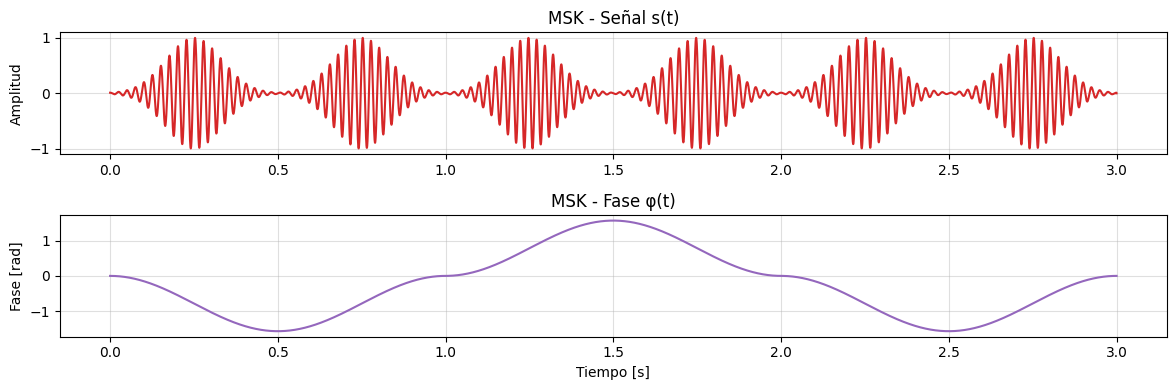

In [6]:
# Inicializar sistema
bits = [0, 1, 1, 0, 0, 1]
system = DigitalModulationSystem(bits, fs=20000, fc_mult=20, T_total=3.0)

# Generar señales
bpsk_env, bpsk_phi, bpsk = system.BPSK()
bfsk_env, bfsk_phi, bfsk = system.BFSK()
cpm_env, cpm_phi, cpm = system.CPM()
msk_env, msk_phi, msk = system.MSK()

# Visualizar cada una
plot_signal(system.t, bpsk, bpsk_phi, "BPSK")
plot_signal(system.t, bfsk, bfsk_phi, "BFSK")
plot_signal(system.t, cpm, cpm_phi, "CPM")
plot_signal(system.t, msk, msk_phi, "MSK")


#Comparación espectral

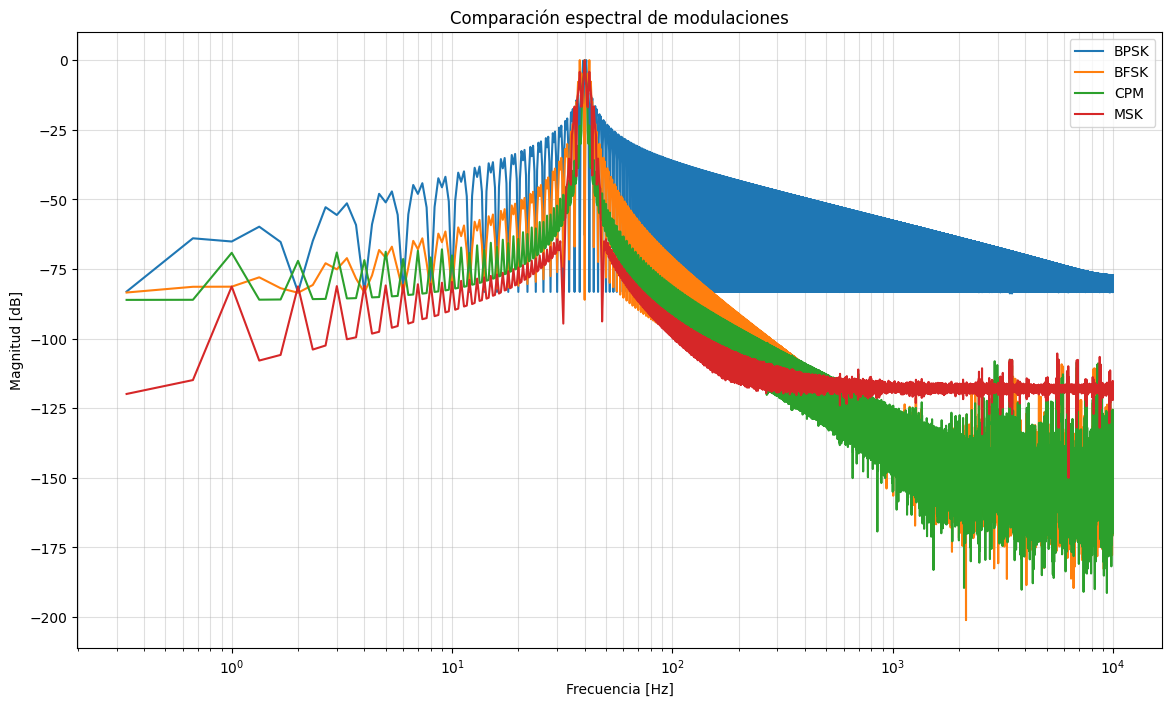

In [7]:
def plot_spectrum(system, signals, names):
    plt.figure(figsize=(14, 8)) # Increased figure size
    for s, name in zip(signals, names):
        S = np.fft.fft(s.numpy())
        f = np.fft.fftfreq(len(S), d=1/system.fs)
        mask = f > 0
        plt.semilogx(f[mask], 20*np.log10(np.abs(S[mask]) / np.max(np.abs(S[mask]))), label=name)
    plt.title("Comparación espectral de modulaciones")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud [dB]")
    plt.grid(True, which='both', alpha=0.4)
    plt.legend()
    plt.show()

plot_spectrum(system, [bpsk, bfsk, cpm, msk], ["BPSK", "BFSK", "CPM", "MSK"])

**Codigo en una sola linea**


SISTEMA COMPLETO DE MODULACIONES DIGITALES

PARÁMETROS DEL SISTEMA
Bits: [1, 0, 1, 1, 0, 1]
N_bits: 6
Tb: 0.5000 s
Rb: 2.00 bits/s
fc: 40.00 Hz
fs: 10000 Hz
Muestras: 30000

GENERANDO SEÑALES

CPM - Verificación de restricciones
W_0 = 12.5664 rad/s
k = 1
W_0·T = 6.283185 rad
2π·k = 6.283185 rad
Diferencia: 0.00e+00


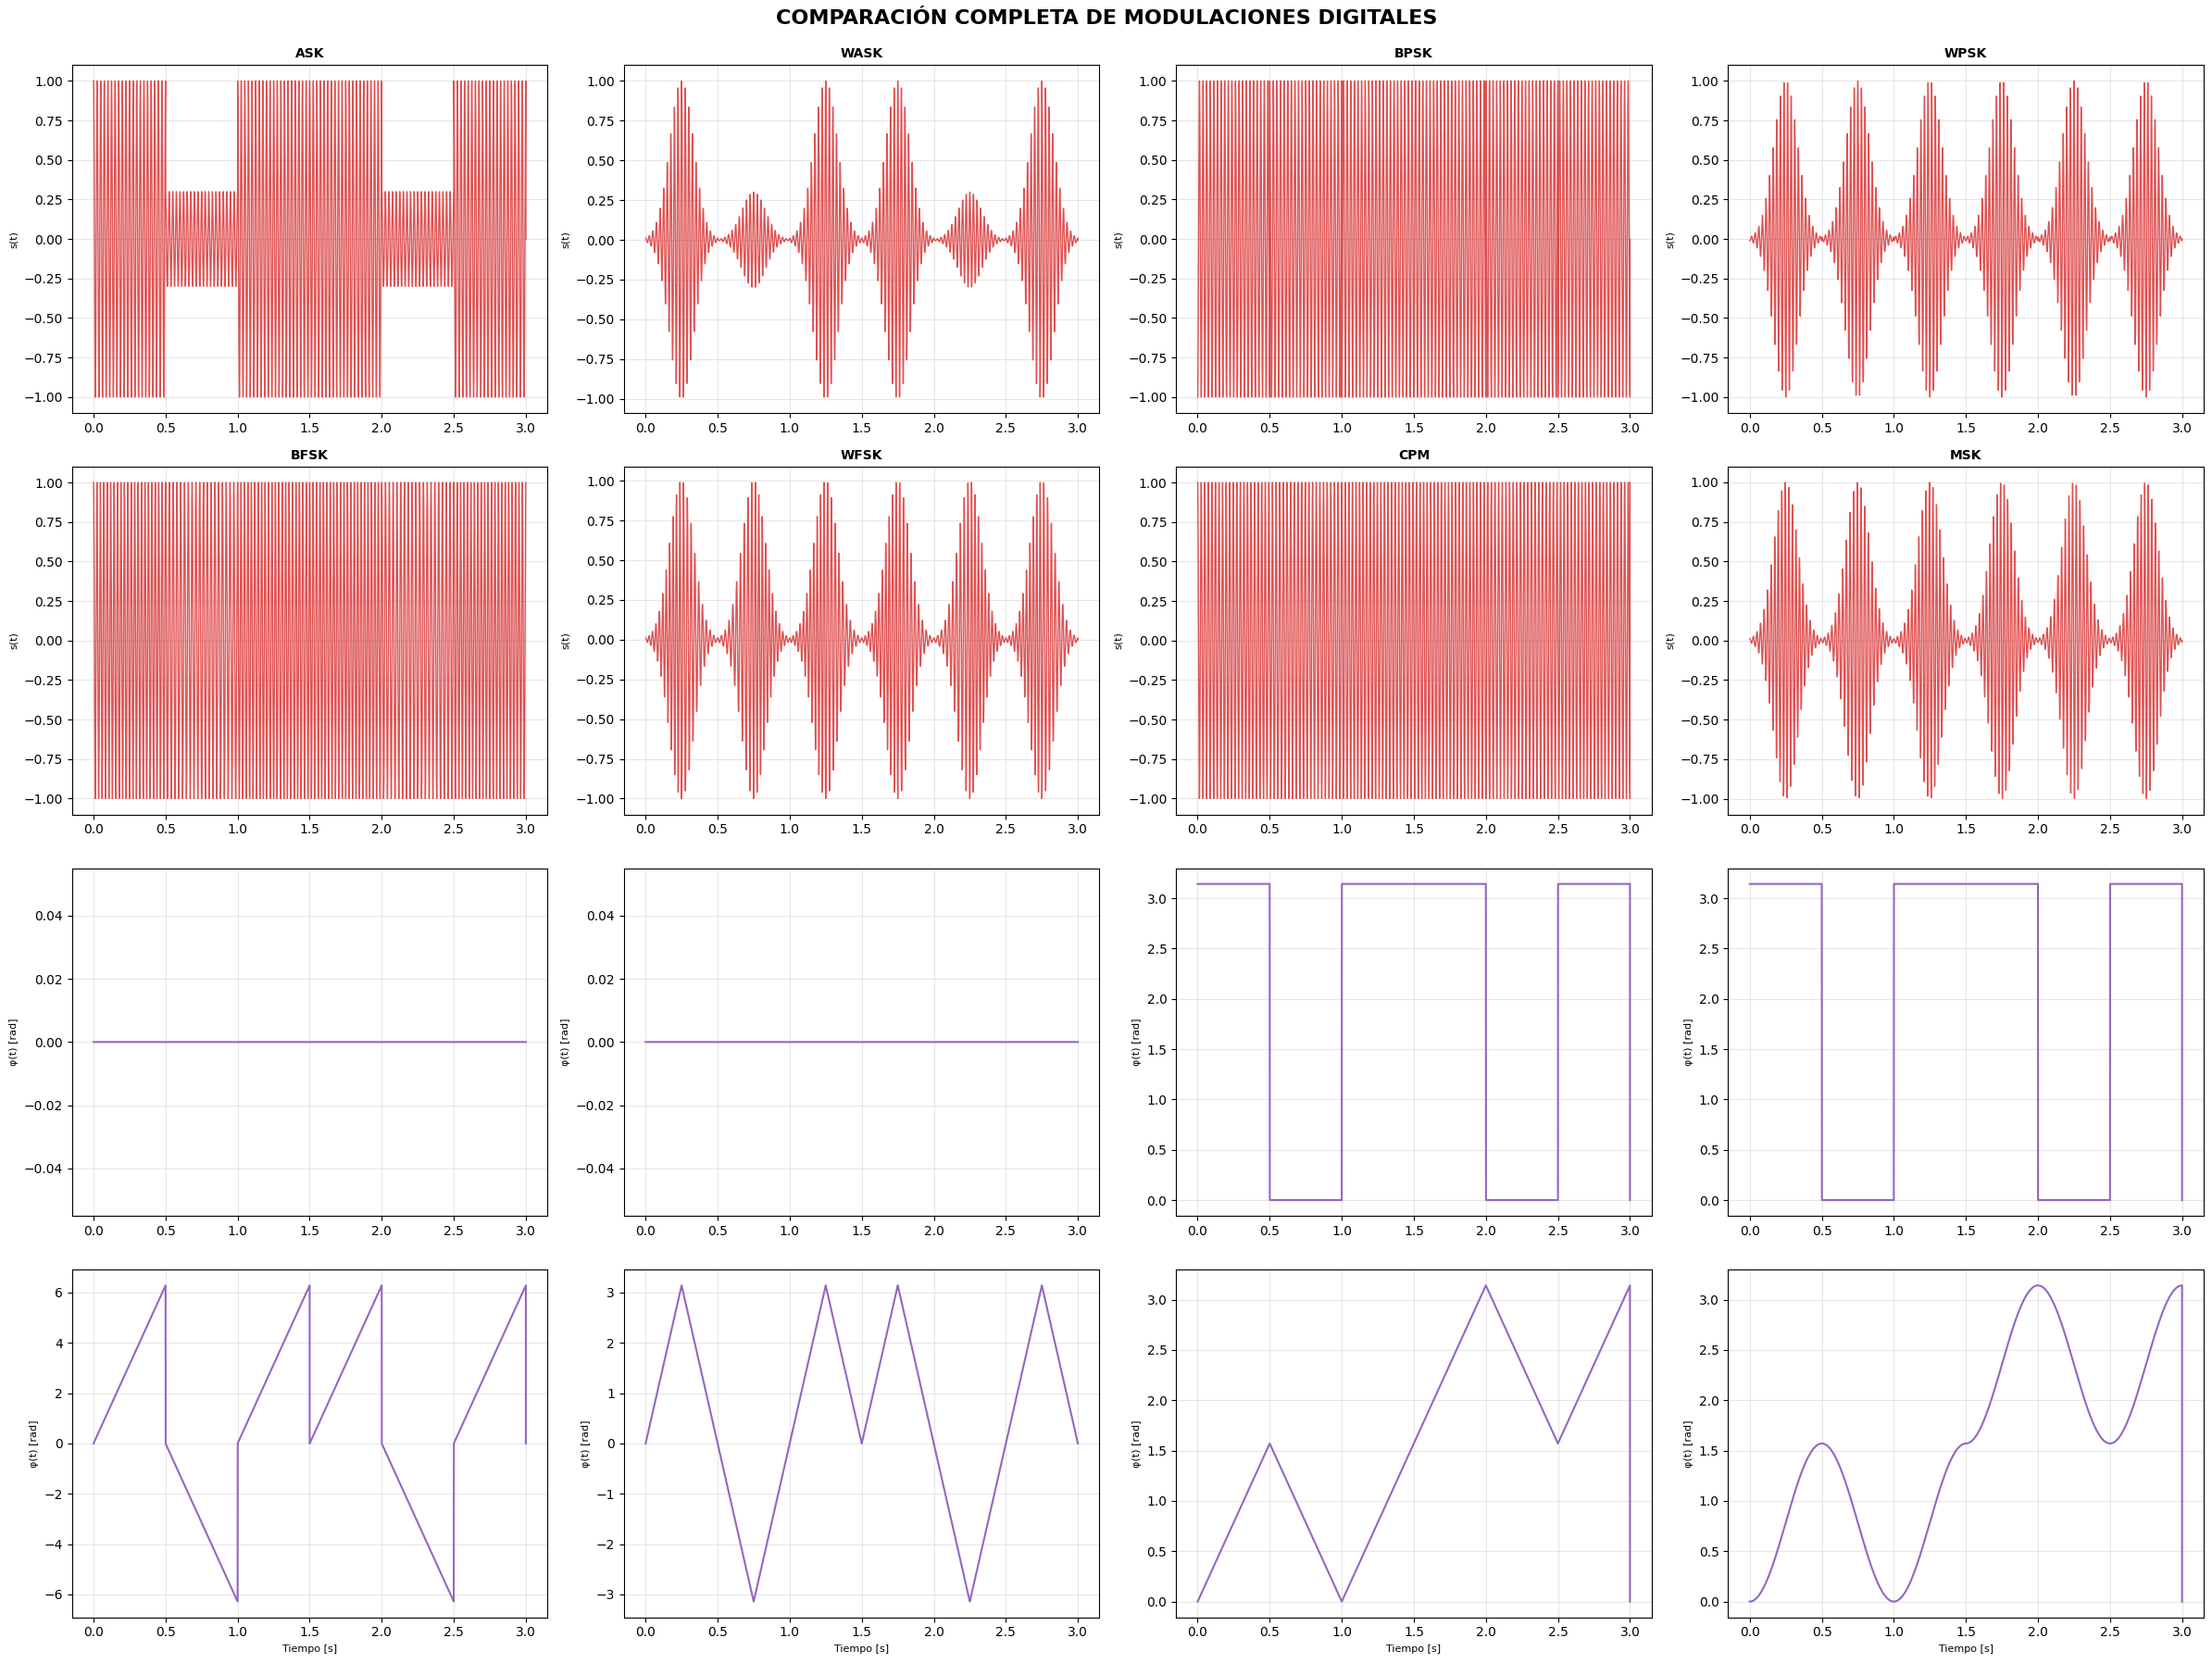

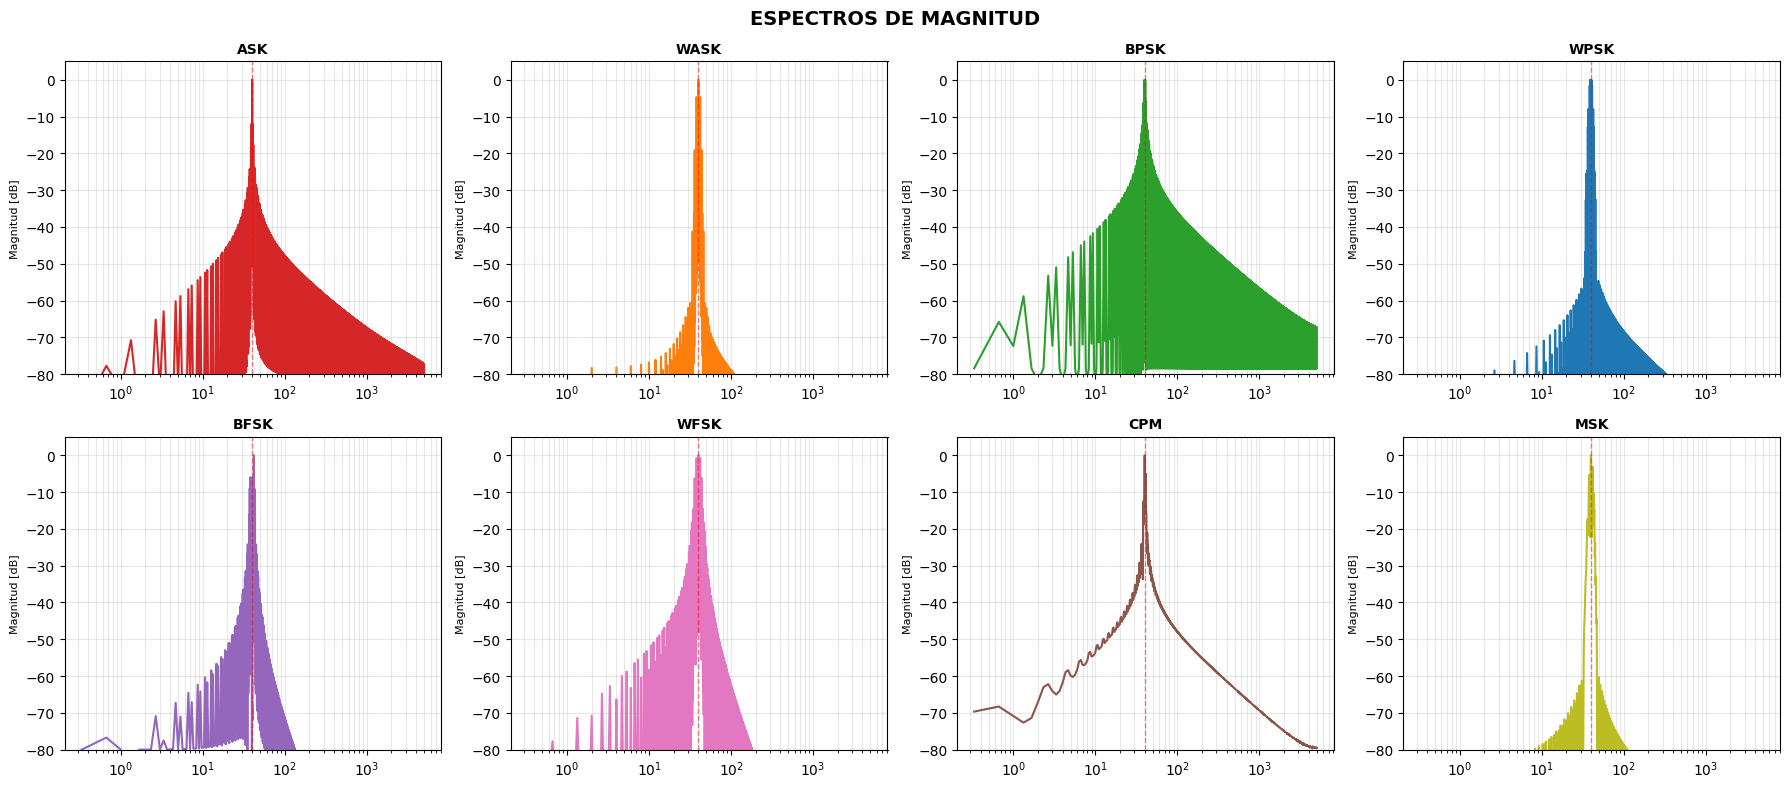


ANÁLISIS DE ORTOGONALIDAD
Δf = 0.50 Hz: ⟨w_1, w_2⟩ = -0.000000 ✓ ORTOGONAL
Δf = 1.00 Hz: ⟨w_1, w_2⟩ = 0.000000 ✓ ORTOGONAL
Δf = 2.00 Hz: ⟨w_1, w_2⟩ = -0.000001 ✓ ORTOGONAL
Δf = 4.00 Hz: ⟨w_1, w_2⟩ = -0.000000 ✓ ORTOGONAL

MÉTRICAS DE DESEMPEÑO

ASK:
  Potencia: 0.348312 | Energía/bit: 0.174156
  BW(-3dB): 0.00 Hz | Eficiencia: inf bits/s/Hz

WASK:
  Potencia: 0.102895 | Energía/bit: 0.051448
  BW(-3dB): 0.00 Hz | Eficiencia: inf bits/s/Hz

BPSK:
  Potencia: 0.499983 | Energía/bit: 0.249992
  BW(-3dB): 1.33 Hz | Eficiencia: 1.5000 bits/s/Hz

WPSK:
  Potencia: 0.147696 | Energía/bit: 0.073848
  BW(-3dB): 2.67 Hz | Eficiencia: 0.7500 bits/s/Hz

BFSK:
  Potencia: 0.500017 | Energía/bit: 0.250008
  BW(-3dB): 0.00 Hz | Eficiencia: inf bits/s/Hz

WFSK:
  Potencia: 0.147696 | Energía/bit: 0.073848
  BW(-3dB): 4.00 Hz | Eficiencia: 0.5000 bits/s/Hz

CPM:
  Potencia: 0.500017 | Energía/bit: 0.250008
  BW(-3dB): 0.00 Hz | Eficiencia: inf bits/s/Hz

MSK:
  Potencia: 0.147696 | Energía/bit: 0.0738

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CLASE PRINCIPAL: Sistema de Modulaciones Digitales Completo
# ============================================================================
class ComprehensiveDigitalModulationSystem:
    """
    Sistema completo que implementa TODAS las modulaciones:

    GRUPO 1 - Modulaciones básicas (ASK/WASK):
    1. ASK: v_i(t) = rect_T(t), amplitud variable
    2. WASK: v_i(t) = gauss_T(t), amplitud variable

    GRUPO 2 - Modulaciones avanzadas:
    3. BPSK: v_i(t) = rect_T(t), φ_i(t) = d_i·π
    4. WPSK: v_i(t) = gauss_T(t), φ_i(t) = d_i·π
    5. BFSK: φ_i(t) = (2d_i - 1)·t [fase lineal]
    6. WFSK: φ_i(t) = (2d_i - 1)·Λ[(t-T)/T] [fase triangular]
    7. CPM: W_0·T = 2π·k, condición de ortogonalidad
    8. MSK: v_i(t) = gauss(t), h = 0.5
    """

    def __init__(self, fs: int = 10000, T_total: float = 3.0,
                 fc_multiplier: int = 20, a0: float = 0.3,
                 a1: float = 1.0, device: str = 'cpu'):
        self.device = torch.device(device)
        self.fs = fs
        self.T_total = T_total
        self.fc_multiplier = fc_multiplier
        self.a0 = a0
        self.a1 = a1

        self.d = None
        self.N_bits = None
        self.Tb = None
        self.Rb = None
        self.fc = None
        self.t = None
        self.n_samples = None

    def set_bit_sequence(self, d: List[int]):
        """Establece la secuencia de bits y calcula parámetros."""
        self.d = torch.tensor(d, dtype=torch.float32, device=self.device)
        self.N_bits = len(d)
        self.Tb = self.T_total / self.N_bits
        self.Rb = 1.0 / self.Tb
        self.fc = self.fc_multiplier * self.Rb
        self.n_samples = int(self.fs * self.T_total)
        self.t = torch.linspace(0, self.T_total, self.n_samples, device=self.device)

        print(f"\n{'='*70}")
        print(f"PARÁMETROS DEL SISTEMA")
        print(f"{'='*70}")
        print(f"Bits: {d}")
        print(f"N_bits: {self.N_bits}")
        print(f"Tb: {self.Tb:.4f} s")
        print(f"Rb: {self.Rb:.2f} bits/s")
        print(f"fc: {self.fc:.2f} Hz")
        print(f"fs: {self.fs} Hz")
        print(f"Muestras: {self.n_samples}")

    # ========================================================================
    # GRUPO 1: ASK/WASK - Modulación de amplitud
    # ========================================================================

    def generate_ask(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """ASK: v_i(t) = rect_T(t), amplitud {a0, a1}"""
        envelope = torch.zeros_like(self.t)
        phase = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            amp = self.a1 if self.d[i] == 1 else self.a0
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)
            envelope[mask] = amp  # rect_T(t)
            phase[mask] = 0  # Sin modulación de fase

        s_ask = envelope * torch.cos(2 * np.pi * self.fc * self.t)
        return envelope, phase, s_ask

    def generate_wask(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """WASK: v_i(t) = gauss_T(t), amplitud {a0, a1}"""
        envelope = torch.zeros_like(self.t)
        phase = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            amp = self.a1 if self.d[i] == 1 else self.a0
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)
            t_center = (t_start + t_end) / 2
            sigma = self.Tb / 6
            t_local = self.t[mask]
            envelope[mask] = amp * torch.exp(-0.5 * ((t_local - t_center) / sigma) ** 2)
            phase[mask] = 0

        s_wask = envelope * torch.cos(2 * np.pi * self.fc * self.t)
        return envelope, phase, s_wask

    # ========================================================================
    # GRUPO 2: BPSK/WPSK - Modulación de fase binaria
    # ========================================================================

    def generate_bpsk(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """BPSK: v_i(t) = rect_T(t), φ_i(t) = d_i·π"""
        envelope = torch.zeros_like(self.t)
        phase = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)
            envelope[mask] = 1.0  # rect_T(t)
            phase[mask] = self.d[i] * np.pi  # φ_i = d_i·π

        s_bpsk = envelope * torch.cos(2 * np.pi * self.fc * self.t + phase)
        return envelope, phase, s_bpsk

    def generate_wpsk(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """WPSK: v_i(t) = gauss_T(t), φ_i(t) = d_i·π"""
        envelope = torch.zeros_like(self.t)
        phase = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)
            t_center = (t_start + t_end) / 2
            sigma = self.Tb / 6
            t_local = self.t[mask]
            envelope[mask] = self.a1 * torch.exp(-0.5 * ((t_local - t_center) / sigma) ** 2)
            phase[mask] = self.d[i] * np.pi  # φ_i = d_i·π

        s_wpsk = envelope * torch.cos(2 * np.pi * self.fc * self.t + phase)
        return envelope, phase, s_wpsk

    # ========================================================================
    # GRUPO 3: BFSK/WFSK - Modulación de frecuencia
    # ========================================================================

    def generate_bfsk(self, delta_f: float = None) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """BFSK: φ_i(t) = (2d_i - 1)·t [fase lineal]"""
        if delta_f is None:
            delta_f = self.Rb

        envelope = torch.ones_like(self.t)
        phase = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)
            t_local = self.t[mask] - t_start
            # φ_i(t) = (2d_i - 1)·t
            phase[mask] = 2 * np.pi * delta_f * (2 * self.d[i] - 1) * t_local

        s_bfsk = envelope * torch.cos(2 * np.pi * self.fc * self.t + phase)
        return envelope, phase, s_bfsk

    def generate_wfsk(self, delta_f: float = None) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """WFSK: φ_i(t) = (2d_i - 1)·Λ[(t-T)/T] [fase triangular]"""
        if delta_f is None:
            delta_f = self.Rb / 2

        envelope = torch.zeros_like(self.t)
        phase = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)
            t_center = (t_start + t_end) / 2
            sigma = self.Tb / 6
            t_local = self.t[mask]

            # Envolvente gaussiana
            envelope[mask] = self.a1 * torch.exp(-0.5 * ((t_local - t_center) / sigma) ** 2)

            # Fase triangular: Λ(x)
            t_norm = (t_local - t_start) / self.Tb
            lambda_func = torch.where(t_norm <= 0.5,
                                     2 * t_norm,
                                     2 * (1 - t_norm))
            phase[mask] = (2 * self.d[i] - 1) * 2 * np.pi * delta_f * self.Tb * lambda_func

        s_wfsk = envelope * torch.cos(2 * np.pi * self.fc * self.t + phase)
        return envelope, phase, s_wfsk

    # ========================================================================
    # GRUPO 4: CPM/MSK - Modulación de fase continua
    # ========================================================================

    def generate_cpm(self, h: float = 0.5, k: int = 1) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """CPM: s.t. W_0·T = 2π·k, k ∈ ℤ (condición de ortogonalidad)"""
        W0 = 2 * np.pi * k / self.Tb

        print(f"\n{'='*70}")
        print(f"CPM - Verificación de restricciones")
        print(f"{'='*70}")
        print(f"W_0 = {W0:.4f} rad/s")
        print(f"k = {k}")
        print(f"W_0·T = {W0 * self.Tb:.6f} rad")
        print(f"2π·k = {2*np.pi*k:.6f} rad")
        print(f"Diferencia: {abs(W0 * self.Tb - 2*np.pi*k):.2e}")

        envelope = torch.ones_like(self.t)
        phase = torch.zeros_like(self.t)
        symbols = 2 * self.d - 1
        phase_accum = 0

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)
            t_local = self.t[mask] - t_start
            q_t = t_local / self.Tb
            delta_phase = np.pi * h * symbols[i] * q_t
            phase[mask] = phase_accum + delta_phase
            phase_accum += np.pi * h * symbols[i]

        s_cpm = envelope * torch.cos(2 * np.pi * self.fc * self.t + phase)
        return envelope, phase, s_cpm

    def generate_msk(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """MSK: v_i(t) = gauss(t), h = 0.5 (mínima condición de ortogonalidad)"""
        envelope = torch.zeros_like(self.t)
        phase = torch.zeros_like(self.t)
        symbols = 2 * self.d - 1
        phase_accum = 0

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)
            t_local = self.t[mask] - t_start
            t_center = self.Tb / 2
            sigma = self.Tb / 6

            # v_i(t) = gauss(t)
            envelope[mask] = torch.exp(-0.5 * ((t_local - t_center) / sigma) ** 2)

            # Fase continua suavizada
            q_t = 0.5 * (1 - torch.cos(np.pi * t_local / self.Tb))
            delta_phase = (np.pi / 2) * symbols[i] * q_t
            phase[mask] = phase_accum + delta_phase
            phase_accum += (np.pi / 2) * symbols[i]

        s_msk = envelope * torch.cos(2 * np.pi * self.fc * self.t + phase)
        return envelope, phase, s_msk

    # ========================================================================
    # UTILIDADES
    # ========================================================================

    def compute_spectrum(self, signal: torch.Tensor) -> Tuple[np.ndarray, np.ndarray]:
        """Calcula el espectro de magnitud."""
        signal_np = signal.cpu().numpy()
        S = np.fft.fft(signal_np)
        freqs = np.fft.fftfreq(len(signal_np), d=1/self.fs)
        mask_pos = freqs > 0
        freqs_pos = freqs[mask_pos]
        S_pos = np.abs(S[mask_pos])
        S_pos_norm = S_pos / (S_pos.max() + 1e-12)
        S_pos_db = 20 * np.log10(S_pos_norm + 1e-12)
        return freqs_pos, S_pos_db

    def verify_orthogonality(self, freq1: float, freq2: float) -> float:
        """Verifica condición ⟨w_2, w_1⟩ = 0"""
        t_test = torch.linspace(0, self.Tb, 1000, device=self.device)
        w1 = 2 * np.pi * freq1 * t_test
        w2 = 2 * np.pi * freq2 * t_test
        cos1 = torch.cos(w1)
        cos2 = torch.cos(w2)
        inner_product = torch.trapezoid(cos1 * cos2, t_test)
        norm1 = torch.sqrt(torch.trapezoid(cos1 ** 2, t_test))
        norm2 = torch.sqrt(torch.trapezoid(cos2 ** 2, t_test))
        return (inner_product / (norm1 * norm2)).item()


# ============================================================================
# VISUALIZACIÓN COMPLETA
# ============================================================================
def plot_complete_comparison(system, all_signals):
    """Visualiza todas las modulaciones en una sola figura."""
    fig = plt.figure(figsize=(24, 18)) # Increased figure size
    fig.suptitle('COMPARACIÓN COMPLETA DE MODULACIONES DIGITALES',
                 fontsize=16, fontweight='bold', y=0.995)

    t_np = system.t.cpu().numpy()
    d_np = system.d.cpu().numpy()

    # Crear onda de bits
    bit_wave = np.zeros_like(t_np)
    for i, bit in enumerate(d_np):
        t_start = i * system.Tb
        t_end = (i + 1) * system.Tb
        mask = (t_np >= t_start) & (t_np < t_end)
        bit_wave[mask] = bit

    mod_names = ['ASK', 'WASK', 'BPSK', 'WPSK', 'BFSK', 'WFSK', 'CPM', 'MSK']

    for idx, (name, (env, phase, sig)) in enumerate(zip(mod_names, all_signals)):
        # Señal modulada
        ax1 = plt.subplot(4, 4, idx + 1)
        sig_np = sig.cpu().numpy()
        ax1.plot(t_np, sig_np, linewidth=1, color='tab:red', alpha=0.8)
        ax1.set_title(f'{name}', fontsize=10, fontweight='bold')
        ax1.set_ylabel('s(t)', fontsize=8)
        ax1.grid(True, alpha=0.3)

        # Fase
        ax2 = plt.subplot(4, 4, idx + 9)
        phase_np = phase.cpu().numpy()
        ax2.plot(t_np, phase_np, linewidth=1.5, color='tab:purple')
        ax2.set_ylabel('φ(t) [rad]', fontsize=8)
        ax2.grid(True, alpha=0.3)

        if idx >= 4:
            ax2.set_xlabel('Tiempo [s]', fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_spectral_comparison(system, all_signals, mod_names):
    """Comparación espectral de todas las modulaciones."""
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle('ESPECTROS DE MAGNITUD', fontsize=14, fontweight='bold')

    axes = axes.flatten()
    colors = ['tab:red', 'tab:orange', 'tab:green', 'tab:blue',
              'tab:purple', 'tab:pink', 'tab:brown', 'tab:olive']

    for idx, (name, (_, _, sig)) in enumerate(zip(mod_names, all_signals)):
        freqs, mag_db = system.compute_spectrum(sig)
        axes[idx].semilogx(freqs, mag_db, linewidth=1.5, color=colors[idx])
        axes[idx].axvline(system.fc, color='red', linestyle='--',
                         linewidth=1, alpha=0.5)
        axes[idx].set_title(name, fontsize=10, fontweight='bold')
        axes[idx].set_ylabel('Magnitud [dB]', fontsize=8)
        axes[idx].grid(True, which='both', alpha=0.3)
        axes[idx].set_ylim([-80, 5])

    plt.tight_layout()
    plt.show()


def print_analysis(system, all_signals, mod_names):
    """Análisis numérico completo."""
    print(f"\n{'='*70}")
    print("ANÁLISIS DE ORTOGONALIDAD")
    print(f"{'='*70}")

    delta_fs = [system.Rb/4, system.Rb/2, system.Rb, 2*system.Rb]
    for delta_f in delta_fs:
        f1 = system.fc - delta_f
        f2 = system.fc + delta_f
        orth = system.verify_orthogonality(f1, f2)
        status = "✓ ORTOGONAL" if abs(orth) < 0.01 else "✗ No ortogonal"
        print(f"Δf = {delta_f:.2f} Hz: ⟨w_1, w_2⟩ = {orth:.6f} {status}")

    print(f"\n{'='*70}")
    print("MÉTRICAS DE DESEMPEÑO")
    print(f"{'='*70}")

    for name, (_, _, sig) in zip(mod_names, all_signals):
        power = torch.mean(sig ** 2).item()
        energy = power * system.Tb
        freqs, mag_db = system.compute_spectrum(sig)
        bw_mask = mag_db > (mag_db.max() - 3)
        bw = freqs[bw_mask].max() - freqs[bw_mask].min() if np.any(bw_mask) else 0

        print(f"\n{name}:")
        print(f"  Potencia: {power:.6f} | Energía/bit: {energy:.6f}")
        print(f"  BW(-3dB): {bw:.2f} Hz | Eficiencia: {system.Rb/bw:.4f} bits/s/Hz")


# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================
if __name__ == "__main__":
    print(f"\n{'='*70}")
    print("SISTEMA COMPLETO DE MODULACIONES DIGITALES")
    print(f"{'='*70}")

    # Crear sistema
    system = ComprehensiveDigitalModulationSystem(
        fs=10000, T_total=3.0, fc_multiplier=20,
        a0=0.3, a1=1.0, device='cpu'
    )

    # Establecer bits
    bits = [1, 0, 1, 1, 0, 1]
    system.set_bit_sequence(bits)

    # Generar TODAS las modulaciones
    print(f"\n{'='*70}")
    print("GENERANDO SEÑALES")
    print(f"{'='*70}")

    ask = system.generate_ask()
    wask = system.generate_wask()
    bpsk = system.generate_bpsk()
    wpsk = system.generate_wpsk()
    bfsk = system.generate_bfsk()
    wfsk = system.generate_wfsk()
    cpm = system.generate_cpm(h=0.5, k=1)
    msk = system.generate_msk()

    all_signals = [ask, wask, bpsk, wpsk, bfsk, wfsk, cpm, msk]
    mod_names = ['ASK', 'WASK', 'BPSK', 'WPSK', 'BFSK', 'WFSK', 'CPM', 'MSK']

    # Visualizar y analizar
    plot_complete_comparison(system, all_signals)
    plot_spectral_comparison(system, all_signals, mod_names)
    print_analysis(system, all_signals, mod_names)

    print(f"\n{'='*70}")
    print("✓ SIMULACIÓN COMPLETADA")
    print(f"{'='*70}\n")


SISTEMA DE MODULACIONES DIGITALES
BPSK | BFSK | CPM | MSK

PARÁMETROS DEL SISTEMA
Secuencia de bits: [1, 0, 1, 1, 0, 1]
Número de bits (N): 6
Duración por bit (Tb): 0.5000 s
Tasa de bits (Rb): 2.00 bits/s
Frecuencia portadora (fc): 40.00 Hz
Frecuencia de muestreo (fs): 10000 Hz
Total de muestras: 30000

GENERANDO SEÑALES MODULADAS

CPM - Verificación de restricción de ortogonalidad
Índice de modulación (h): 0.5
Factor k: 1
W_0 calculado: 12.5664 rad/s
W_0·T = 6.283185 rad
2π·k = 6.283185 rad
Diferencia: 0.00e+00 rad
✓ Condición de ortogonalidad cumplida
✓ BPSK generado
✓ BFSK generado
✓ CPM generado
✓ MSK generado

GENERANDO VISUALIZACIONES


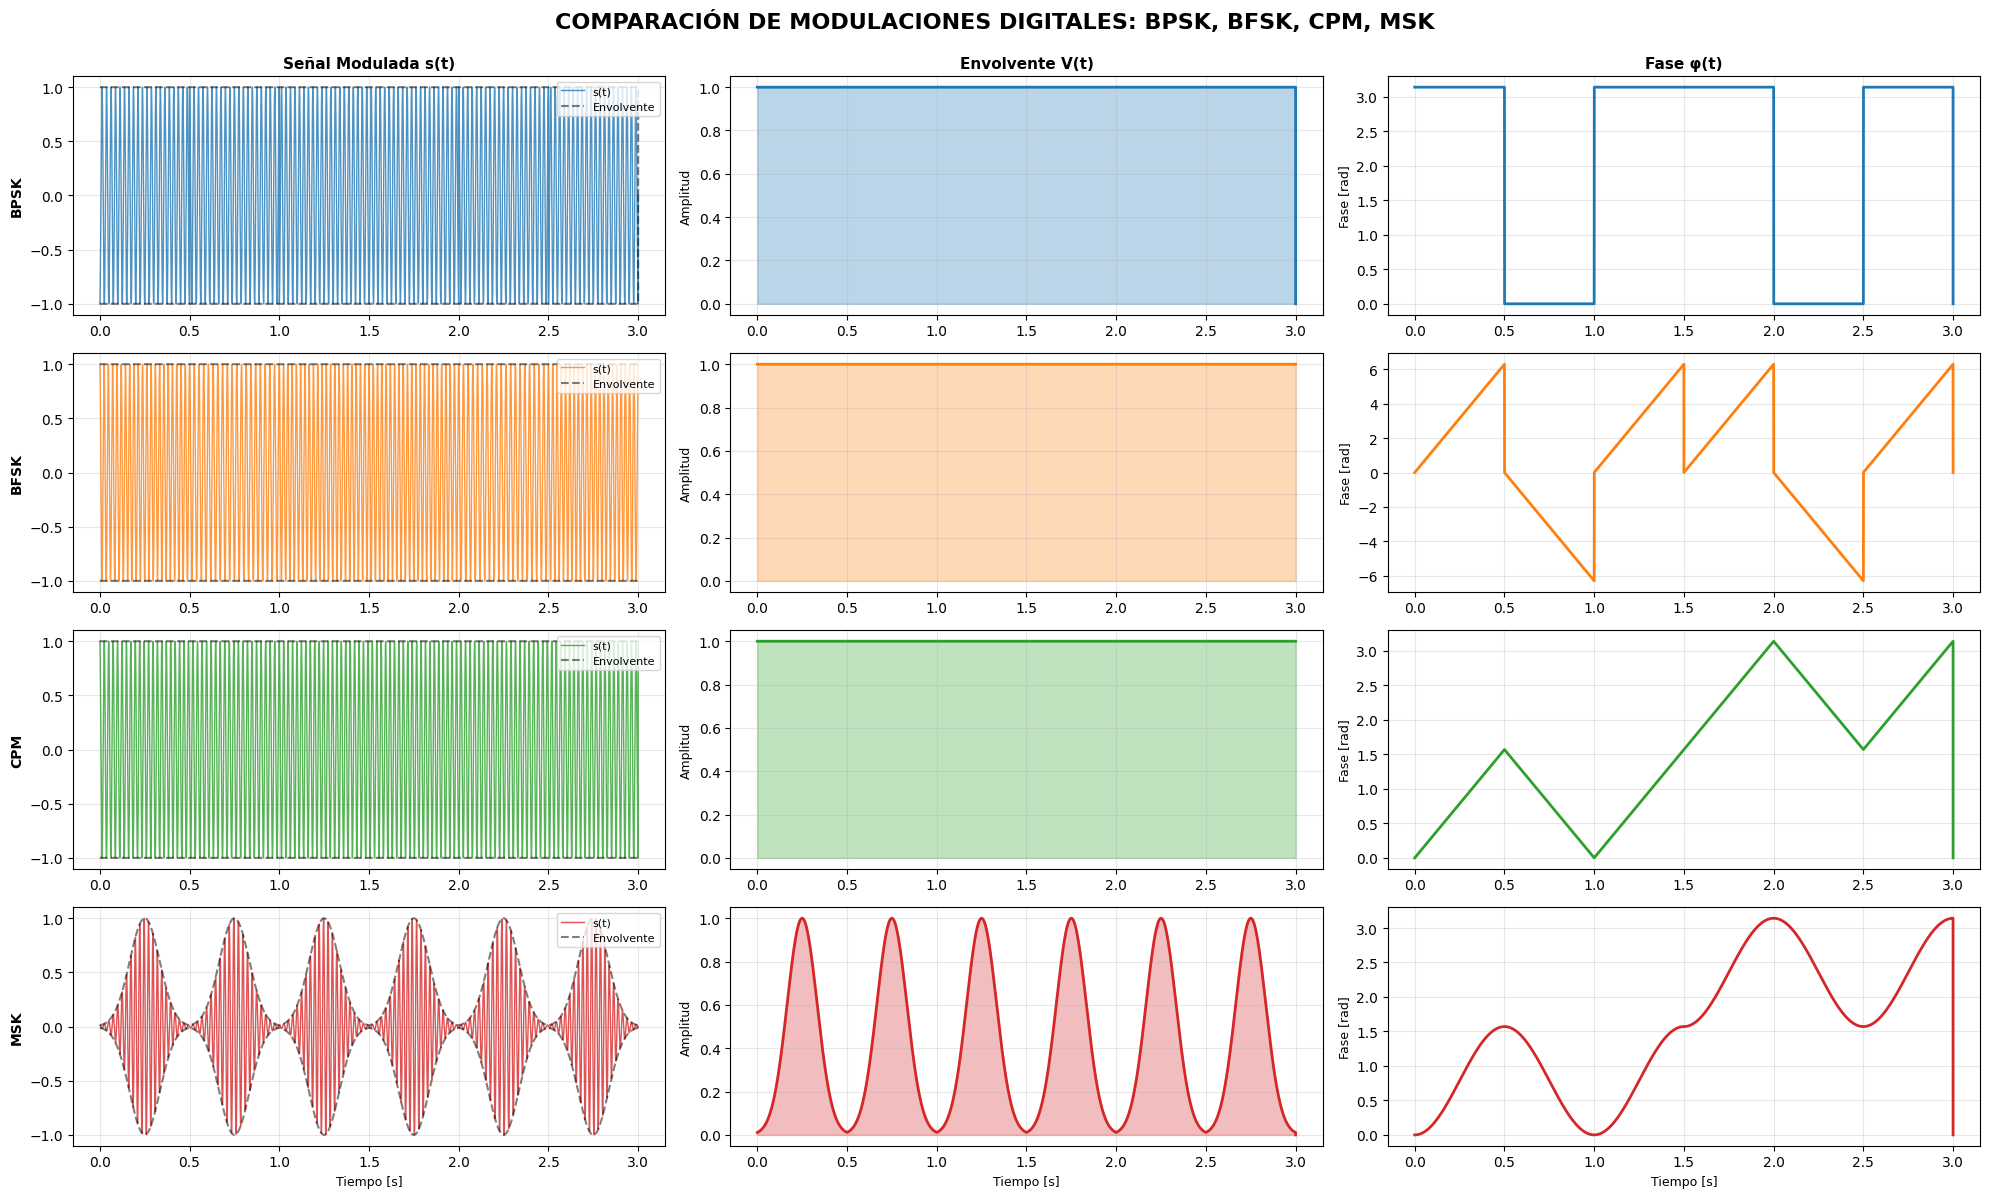

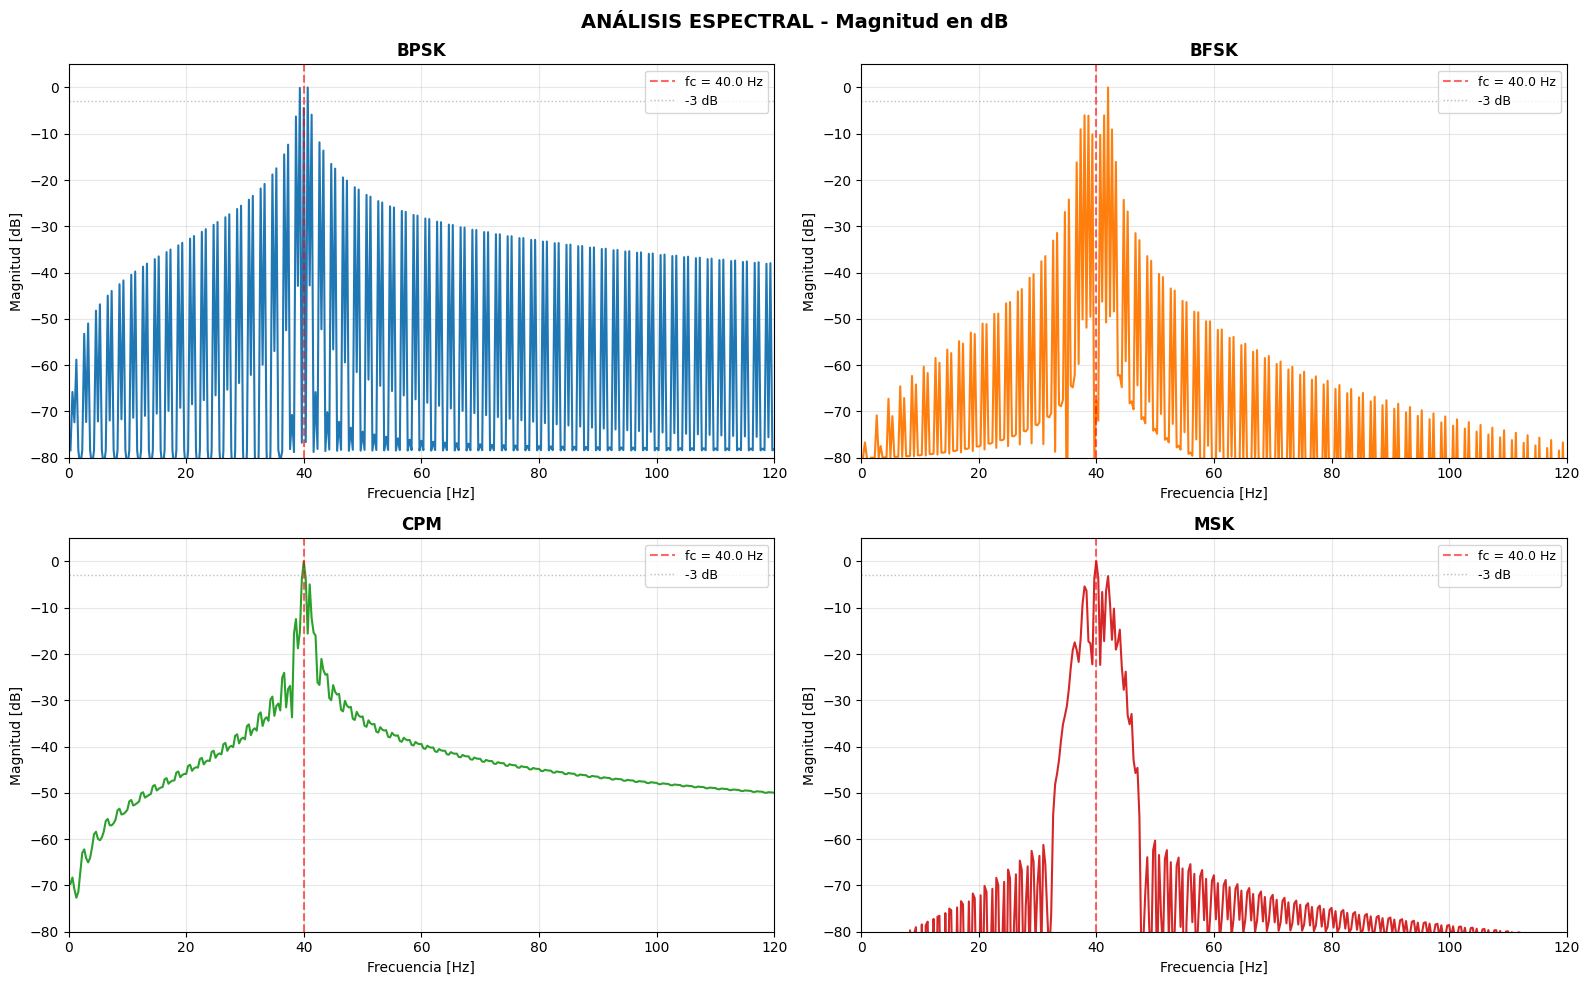

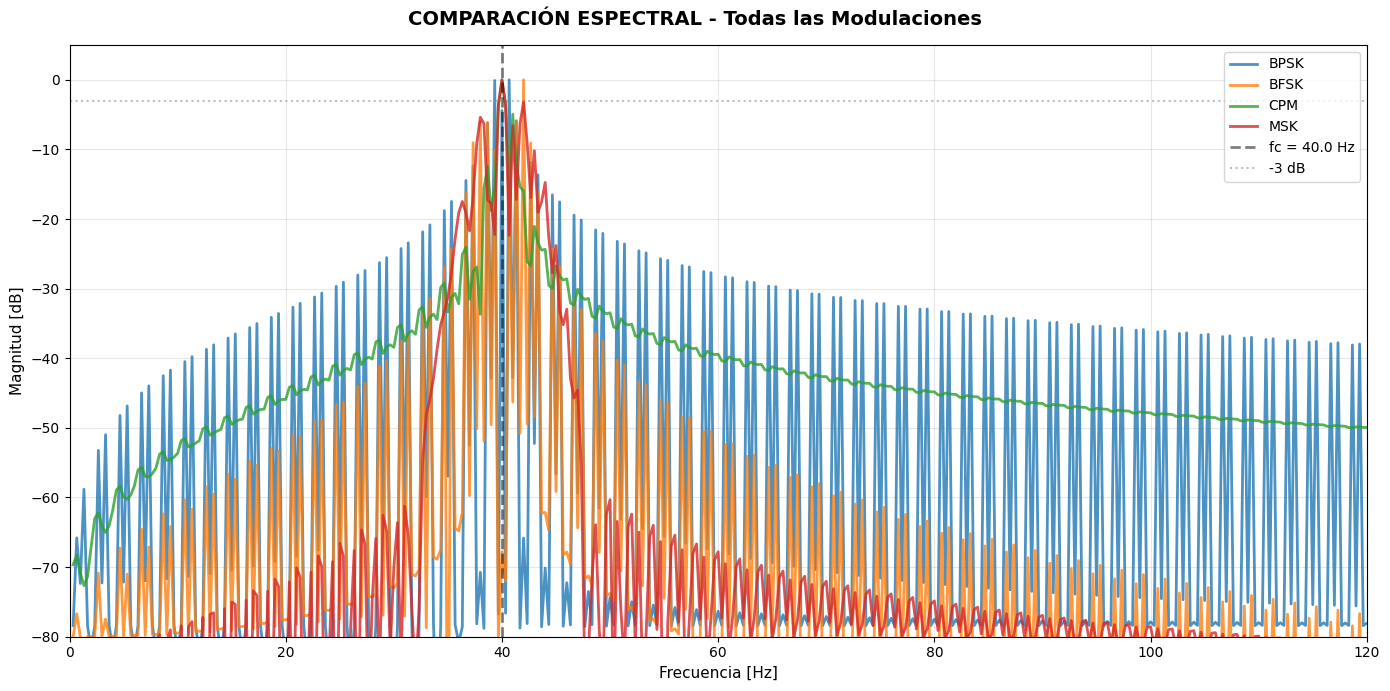


ANÁLISIS DE ORTOGONALIDAD
Δf =   0.50 Hz: ⟨w_1, w_2⟩ = -0.000000  ✓ ORTOGONAL
Δf =   1.00 Hz: ⟨w_1, w_2⟩ = 0.000000  ✓ ORTOGONAL
Δf =   2.00 Hz: ⟨w_1, w_2⟩ = -0.000001  ✓ ORTOGONAL
Δf =   4.00 Hz: ⟨w_1, w_2⟩ = -0.000000  ✓ ORTOGONAL

MÉTRICAS COMPARATIVAS DE DESEMPEÑO
Modulación       Potencia        E/bit      BW [Hz]   η [b/s/Hz]
----------------------------------------------------------------------
BPSK             0.499983     0.249992         1.33       1.5000
BFSK             0.500017     0.250008         0.00       0.0000
CPM              0.500017     0.250008         0.00       0.0000
MSK              0.147696     0.073848         0.00       0.0000

ANÁLISIS COMPARATIVO
✓ Mayor eficiencia espectral: BPSK (1.5000 b/s/Hz)
✓ Menor ancho de banda: BFSK (0.00 Hz)
✓ Mayor potencia promedio: CPM (0.500017)

CARACTERÍSTICAS ESPECIALES
BPSK: Fase discontinua, alta eficiencia espectral
BFSK: Frecuencia variable, más robusto a ruido
CPM:  Fase continua, cumple W_0·T = 2πk (ortogonalidad)

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# SISTEMA DE MODULACIONES DIGITALES: BPSK, BFSK, CPM, MSK
# ============================================================================
class DigitalModulationSystem:
    """
    Sistema que implementa 4 modulaciones digitales:

    1. BPSK: V_i(t) = rect_T(t), φ_i(t) = d_i·π
    2. BFSK: φ_i(t) = (2d_i - 1)·t
    3. CPM: s.t. W_0·T = 2π·k, k ∈ ℤ (condición de ortogonalidad)
    4. MSK: v_i(t) = Gauss (mínima condición de ortogonalidad, h=0.5)
    """

    def __init__(self, fs: int = 10000, T_total: float = 3.0,
                 fc_multiplier: int = 20, device: str = 'cpu'):
        self.device = torch.device(device)
        self.fs = fs
        self.T_total = T_total
        self.fc_multiplier = fc_multiplier

        self.d = None
        self.N_bits = None
        self.Tb = None
        self.Rb = None
        self.fc = None
        self.t = None
        self.n_samples = None

    def set_bit_sequence(self, d: List[int]):
        """Establece la secuencia de bits y calcula parámetros del sistema."""
        self.d = torch.tensor(d, dtype=torch.float32, device=self.device)
        self.N_bits = len(d)
        self.Tb = self.T_total / self.N_bits
        self.Rb = 1.0 / self.Tb
        self.fc = self.fc_multiplier * self.Rb
        self.n_samples = int(self.fs * self.T_total)
        self.t = torch.linspace(0, self.T_total, self.n_samples, device=self.device)

        print(f"\n{'='*70}")
        print(f"PARÁMETROS DEL SISTEMA")
        print(f"{'='*70}")
        print(f"Secuencia de bits: {d}")
        print(f"Número de bits (N): {self.N_bits}")
        print(f"Duración por bit (Tb): {self.Tb:.4f} s")
        print(f"Tasa de bits (Rb): {self.Rb:.2f} bits/s")
        print(f"Frecuencia portadora (fc): {self.fc:.2f} Hz")
        print(f"Frecuencia de muestreo (fs): {self.fs} Hz")
        print(f"Total de muestras: {self.n_samples}")

    # ========================================================================
    # BPSK: V_i(t) = rect_T(t), φ_i(t) = d_i·π
    # ========================================================================
    def generate_bpsk(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        BPSK (Binary Phase Shift Keying)
        - Envolvente: V_i(t) = rect_T(t) = 1 para todo t ∈ [iT, (i+1)T]
        - Fase: φ_i(t) = d_i·π (0 o π según el bit)
        """
        envelope = torch.zeros_like(self.t)
        phase = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)

            # Envolvente rectangular constante
            envelope[mask] = 1.0

            # Fase binaria: 0 o π
            phase[mask] = self.d[i] * np.pi

        # Señal modulada
        s_bpsk = envelope * torch.cos(2 * np.pi * self.fc * self.t + phase)

        return envelope, phase, s_bpsk

    # ========================================================================
    # BFSK: φ_i(t) = (2d_i - 1)·t
    # ========================================================================
    def generate_bfsk(self, delta_f: float = None) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        BFSK (Binary Frequency Shift Keying)
        - Fase: φ_i(t) = (2d_i - 1)·t (fase lineal con el tiempo)
        - delta_f: desviación de frecuencia (por defecto Rb)
        """
        if delta_f is None:
            delta_f = self.Rb

        envelope = torch.ones_like(self.t)
        phase = torch.zeros_like(self.t)

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)

            # Tiempo local dentro del bit
            t_local = self.t[mask] - t_start

            # Fase lineal: φ_i(t) = (2d_i - 1)·t
            # Esto modula la frecuencia: f = fc ± delta_f
            phase[mask] = 2 * np.pi * delta_f * (2 * self.d[i] - 1) * t_local

        # Señal modulada
        s_bfsk = envelope * torch.cos(2 * np.pi * self.fc * self.t + phase)

        return envelope, phase, s_bfsk

    # ========================================================================
    # CPM: s.t. W_0·T = 2π·k, k ∈ ℤ (Condición de ortogonalidad)
    # ========================================================================
    def generate_cpm(self, h: float = 0.5, k: int = 1) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        CPM (Continuous Phase Modulation)
        - Restricción: W_0·T = 2π·k, donde k ∈ ℤ
        - h: índice de modulación (por defecto 0.5)
        - Fase continua entre transiciones de bits
        """
        # Calcular W_0 que cumple la restricción de ortogonalidad
        W0 = 2 * np.pi * k / self.Tb

        print(f"\n{'='*70}")
        print(f"CPM - Verificación de restricción de ortogonalidad")
        print(f"{'='*70}")
        print(f"Índice de modulación (h): {h}")
        print(f"Factor k: {k}")
        print(f"W_0 calculado: {W0:.4f} rad/s")
        print(f"W_0·T = {W0 * self.Tb:.6f} rad")
        print(f"2π·k = {2*np.pi*k:.6f} rad")
        print(f"Diferencia: {abs(W0 * self.Tb - 2*np.pi*k):.2e} rad")
        print(f"✓ Condición de ortogonalidad cumplida" if abs(W0 * self.Tb - 2*np.pi*k) < 1e-10 else "✗ Error en ortogonalidad")

        envelope = torch.ones_like(self.t)
        phase = torch.zeros_like(self.t)

        # Convertir bits a símbolos: {0,1} → {-1,+1}
        symbols = 2 * self.d - 1

        # Acumulador de fase para continuidad
        phase_accum = 0

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)

            t_local = self.t[mask] - t_start

            # Función de fase q(t) = t/T (lineal)
            q_t = t_local / self.Tb

            # Incremento de fase: Δφ = π·h·a_i·q(t)
            delta_phase = np.pi * h * symbols[i] * q_t

            phase[mask] = phase_accum + delta_phase

            # Actualizar acumulador para continuidad
            phase_accum += np.pi * h * symbols[i]

        # Señal modulada
        s_cpm = envelope * torch.cos(2 * np.pi * self.fc * self.t + phase)

        return envelope, phase, s_cpm

    # ========================================================================
    # MSK: v_i(t) = Gauss (Mínima condición de ortogonalidad, h = 0.5)
    # ========================================================================
    def generate_msk(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        MSK (Minimum Shift Keying)
        - Envolvente: v_i(t) = Gauss (pulso Gaussiano)
        - h = 0.5 (índice de modulación mínimo para ortogonalidad)
        - Caso especial de CPM con fase suavizada
        """
        envelope = torch.zeros_like(self.t)
        phase = torch.zeros_like(self.t)

        # Convertir bits a símbolos
        symbols = 2 * self.d - 1

        phase_accum = 0

        for i in range(self.N_bits):
            t_start = i * self.Tb
            t_end = (i + 1) * self.Tb
            mask = (self.t >= t_start) & (self.t < t_end)

            t_local = self.t[mask] - t_start
            t_center = self.Tb / 2
            sigma = self.Tb / 6

            # Envolvente Gaussiana
            envelope[mask] = torch.exp(-0.5 * ((t_local - t_center) / sigma) ** 2)

            # Función de fase suavizada (sinusoidal)
            # q(t) = 0.5 * (1 - cos(π·t/T))
            q_t = 0.5 * (1 - torch.cos(np.pi * t_local / self.Tb))

            # Incremento de fase con h = 0.5
            delta_phase = (np.pi / 2) * symbols[i] * q_t

            phase[mask] = phase_accum + delta_phase

            # Actualizar acumulador
            phase_accum += (np.pi / 2) * symbols[i]

        # Señal modulada
        s_msk = envelope * torch.cos(2 * np.pi * self.fc * self.t + phase)

        return envelope, phase, s_msk

    # ========================================================================
    # FUNCIONES AUXILIARES
    # ========================================================================
    def compute_spectrum(self, signal: torch.Tensor) -> Tuple[np.ndarray, np.ndarray]:
        """Calcula el espectro de magnitud (solo frecuencias positivas)."""
        signal_np = signal.cpu().numpy()
        S = np.fft.fft(signal_np)
        freqs = np.fft.fftfreq(len(signal_np), d=1/self.fs)

        # Solo frecuencias positivas
        mask_pos = freqs > 0
        freqs_pos = freqs[mask_pos]
        S_pos = np.abs(S[mask_pos])

        # Normalizar y convertir a dB
        S_pos_norm = S_pos / (S_pos.max() + 1e-12)
        S_pos_db = 20 * np.log10(S_pos_norm + 1e-12)

        return freqs_pos, S_pos_db

    def verify_orthogonality(self, freq1: float, freq2: float) -> float:
        """
        Verifica la condición de ortogonalidad: ⟨w_1, w_2⟩ = 0
        Retorna el producto interno normalizado.
        """
        t_test = torch.linspace(0, self.Tb, 1000, device=self.device)

        w1 = 2 * np.pi * freq1 * t_test
        w2 = 2 * np.pi * freq2 * t_test

        cos1 = torch.cos(w1)
        cos2 = torch.cos(w2)

        # Producto interno
        inner_product = torch.trapezoid(cos1 * cos2, t_test)

        # Normalización
        norm1 = torch.sqrt(torch.trapezoid(cos1 ** 2, t_test))
        norm2 = torch.sqrt(torch.trapezoid(cos2 ** 2, t_test))

        return (inner_product / (norm1 * norm2)).item()

    def compute_metrics(self, signal: torch.Tensor) -> dict:
        """Calcula métricas de desempeño de la señal."""
        # Potencia promedio
        power = torch.mean(signal ** 2).item()

        # Energía por bit
        energy_per_bit = power * self.Tb

        # Ancho de banda (-3dB)
        freqs, mag_db = self.compute_spectrum(signal)
        bw_mask = mag_db > (mag_db.max() - 3)

        if np.any(bw_mask):
            bw = freqs[bw_mask].max() - freqs[bw_mask].min()
        else:
            bw = 0

        # Eficiencia espectral
        spectral_efficiency = self.Rb / bw if bw > 0 else 0

        return {
            'power': power,
            'energy_per_bit': energy_per_bit,
            'bandwidth': bw,
            'spectral_efficiency': spectral_efficiency
        }


# ============================================================================
# FUNCIONES DE VISUALIZACIÓN
# ============================================================================
def plot_modulation_comparison(system, signals_dict):
    """
    Visualiza todas las modulaciones en una figura comparativa.
    """
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle('COMPARACIÓN DE MODULACIONES DIGITALES: BPSK, BFSK, CPM, MSK',
                 fontsize=16, fontweight='bold', y=0.995)

    t_np = system.t.cpu().numpy()
    d_np = system.d.cpu().numpy()

    # Crear onda de bits para referencia
    bit_wave = np.zeros_like(t_np)
    for i, bit in enumerate(d_np):
        t_start = i * system.Tb
        t_end = (i + 1) * system.Tb
        mask = (t_np >= t_start) & (t_np < t_end)
        bit_wave[mask] = bit

    mod_names = ['BPSK', 'BFSK', 'CPM', 'MSK']
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for idx, name in enumerate(mod_names):
        env, phase, sig = signals_dict[name]

        # Señal modulada
        ax1 = plt.subplot(4, 3, idx*3 + 1)
        sig_np = sig.cpu().numpy()
        env_np = env.cpu().numpy()

        ax1.plot(t_np, sig_np, linewidth=1, color=colors[idx], alpha=0.8, label='s(t)')
        ax1.plot(t_np, env_np, linewidth=1.5, color='black', linestyle='--',
                 alpha=0.5, label='Envolvente')
        ax1.plot(t_np, -env_np, linewidth=1.5, color='black', linestyle='--', alpha=0.5)

        if idx == 0:
            ax1.set_title('Señal Modulada s(t)', fontsize=11, fontweight='bold')
        ax1.set_ylabel(f'{name}', fontsize=10, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='upper right', fontsize=8)

        # Envolvente
        ax2 = plt.subplot(4, 3, idx*3 + 2)
        ax2.plot(t_np, env_np, linewidth=2, color=colors[idx])
        ax2.fill_between(t_np, 0, env_np, alpha=0.3, color=colors[idx])

        if idx == 0:
            ax2.set_title('Envolvente V(t)', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Amplitud', fontsize=9)
        ax2.grid(True, alpha=0.3)

        # Fase
        ax3 = plt.subplot(4, 3, idx*3 + 3)
        phase_np = phase.cpu().numpy()
        ax3.plot(t_np, phase_np, linewidth=2, color=colors[idx])

        if idx == 0:
            ax3.set_title('Fase φ(t)', fontsize=11, fontweight='bold')
        ax3.set_ylabel('Fase [rad]', fontsize=9)
        ax3.grid(True, alpha=0.3)

        if idx == 3:  # Última fila
            ax1.set_xlabel('Tiempo [s]', fontsize=9)
            ax2.set_xlabel('Tiempo [s]', fontsize=9)
            ax3.set_xlabel('Tiempo [s]', fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_spectral_analysis(system, signals_dict):
    """
    Análisis espectral de todas las modulaciones.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('ANÁLISIS ESPECTRAL - Magnitud en dB',
                 fontsize=14, fontweight='bold')

    axes = axes.flatten()
    mod_names = ['BPSK', 'BFSK', 'CPM', 'MSK']
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for idx, name in enumerate(mod_names):
        _, _, sig = signals_dict[name]
        freqs, mag_db = system.compute_spectrum(sig)

        axes[idx].plot(freqs, mag_db, linewidth=1.5, color=colors[idx])
        axes[idx].axvline(system.fc, color='red', linestyle='--',
                         linewidth=1.5, alpha=0.6, label=f'fc = {system.fc:.1f} Hz')
        axes[idx].axhline(-3, color='gray', linestyle=':',
                         linewidth=1, alpha=0.5, label='-3 dB')

        axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Frecuencia [Hz]', fontsize=10)
        axes[idx].set_ylabel('Magnitud [dB]', fontsize=10)
        axes[idx].grid(True, which='both', alpha=0.3)
        axes[idx].set_ylim([-80, 5])
        axes[idx].set_xlim([0, system.fc * 3])
        axes[idx].legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_comparative_spectra(system, signals_dict):
    """
    Comparación directa de todos los espectros en una sola gráfica.
    """
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    fig.suptitle('COMPARACIÓN ESPECTRAL - Todas las Modulaciones',
                 fontsize=14, fontweight='bold')

    mod_names = ['BPSK', 'BFSK', 'CPM', 'MSK']
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for idx, name in enumerate(mod_names):
        _, _, sig = signals_dict[name]
        freqs, mag_db = system.compute_spectrum(sig)
        ax.plot(freqs, mag_db, linewidth=2, color=colors[idx],
                alpha=0.8, label=name)

    ax.axvline(system.fc, color='black', linestyle='--',
               linewidth=2, alpha=0.5, label=f'fc = {system.fc:.1f} Hz')
    ax.axhline(-3, color='gray', linestyle=':',
               linewidth=1.5, alpha=0.5, label='-3 dB')

    ax.set_xlabel('Frecuencia [Hz]', fontsize=11)
    ax.set_ylabel('Magnitud [dB]', fontsize=11)
    ax.grid(True, which='both', alpha=0.3)
    ax.set_ylim([-80, 5])
    ax.set_xlim([0, system.fc * 3])
    ax.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()


def print_comprehensive_analysis(system, signals_dict):
    """
    Análisis numérico completo con comparaciones.
    """
    print(f"\n{'='*70}")
    print("ANÁLISIS DE ORTOGONALIDAD")
    print(f"{'='*70}")

    # Probar diferentes separaciones de frecuencia
    delta_fs = [system.Rb/4, system.Rb/2, system.Rb, 2*system.Rb]

    for delta_f in delta_fs:
        f1 = system.fc - delta_f
        f2 = system.fc + delta_f
        orth = system.verify_orthogonality(f1, f2)
        status = "✓ ORTOGONAL" if abs(orth) < 0.01 else "✗ No ortogonal"
        print(f"Δf = {delta_f:6.2f} Hz: ⟨w_1, w_2⟩ = {orth:8.6f}  {status}")

    print(f"\n{'='*70}")
    print("MÉTRICAS COMPARATIVAS DE DESEMPEÑO")
    print(f"{'='*70}")
    print(f"{'Modulación':<12} {'Potencia':>12} {'E/bit':>12} {'BW [Hz]':>12} {'η [b/s/Hz]':>12}")
    print(f"{'-'*70}")

    metrics_summary = {}

    for name in ['BPSK', 'BFSK', 'CPM', 'MSK']:
        _, _, sig = signals_dict[name]
        metrics = system.compute_metrics(sig)
        metrics_summary[name] = metrics

        print(f"{name:<12} {metrics['power']:12.6f} {metrics['energy_per_bit']:12.6f} "
              f"{metrics['bandwidth']:12.2f} {metrics['spectral_efficiency']:12.4f}")

    # Análisis comparativo
    print(f"\n{'='*70}")
    print("ANÁLISIS COMPARATIVO")
    print(f"{'='*70}")

    # Mejor eficiencia espectral
    best_eff = max(metrics_summary.items(), key=lambda x: x[1]['spectral_efficiency'])
    print(f"✓ Mayor eficiencia espectral: {best_eff[0]} ({best_eff[1]['spectral_efficiency']:.4f} b/s/Hz)")

    # Menor ancho de banda
    min_bw = min(metrics_summary.items(), key=lambda x: x[1]['bandwidth'])
    print(f"✓ Menor ancho de banda: {min_bw[0]} ({min_bw[1]['bandwidth']:.2f} Hz)")

    # Mayor potencia
    max_pow = max(metrics_summary.items(), key=lambda x: x[1]['power'])
    print(f"✓ Mayor potencia promedio: {max_pow[0]} ({max_pow[1]['power']:.6f})")

    # Características especiales
    print(f"\n{'='*70}")
    print("CARACTERÍSTICAS ESPECIALES")
    print(f"{'='*70}")
    print(f"BPSK: Fase discontinua, alta eficiencia espectral")
    print(f"BFSK: Frecuencia variable, más robusto a ruido")
    print(f"CPM:  Fase continua, cumple W_0·T = 2πk (ortogonalidad)")
    print(f"MSK:  Envolvente Gaussiana suave, h = 0.5 (mínima ortogonalidad)")


# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================
if __name__ == "__main__":
    print(f"\n{'='*70}")
    print("SISTEMA DE MODULACIONES DIGITALES")
    print("BPSK | BFSK | CPM | MSK")
    print(f"{'='*70}")

    # Crear sistema
    system = DigitalModulationSystem(
        fs=10000,           # Frecuencia de muestreo
        T_total=3.0,        # Duración total
        fc_multiplier=20,   # fc = 20 * Rb
        device='cpu'
    )

    # Establecer secuencia de bits
    bits = [1, 0, 1, 1, 0, 1]
    system.set_bit_sequence(bits)

    # Generar todas las modulaciones
    print(f"\n{'='*70}")
    print("GENERANDO SEÑALES MODULADAS")
    print(f"{'='*70}")

    signals_dict = {
        'BPSK': system.generate_bpsk(),
        'BFSK': system.generate_bfsk(),
        'CPM': system.generate_cpm(h=0.5, k=1),
        'MSK': system.generate_msk()
    }

    print("✓ BPSK generado")
    print("✓ BFSK generado")
    print("✓ CPM generado")
    print("✓ MSK generado")

    # Visualizaciones
    print(f"\n{'='*70}")
    print("GENERANDO VISUALIZACIONES")
    print(f"{'='*70}")

    plot_modulation_comparison(system, signals_dict)
    plot_spectral_analysis(system, signals_dict)
    plot_comparative_spectra(system, signals_dict)

    # Análisis numérico
    print_comprehensive_analysis(system, signals_dict)

    print(f"\n{'='*70}")
    print("✓ SIMULACIÓN COMPLETADA EXITOSAMENTE")
    print(f"{'='*70}\n")